# AENN extreme-value - Logistic 

The dynamical map and Chapter-4 target are

$$L(x)=4x(1-x),\qquad \zeta_L=\frac34,$$

with $L(3/4)=3/4$ and $|L'(3/4)|=2$, giving the theoretical extremal index

$$\theta=1-\frac{1}{|L'(3/4)|}=\frac12.$$

The three observables use the theoretical GEV shapes

$$\xi_{\mathrm{Gumbel}}=0,\qquad \xi_{\mathrm{Weibull}}=-0.3,\qquad \xi_{\mathrm{Fr\acute echet}}=0.3.$$

## 1 · Environment

In [1]:
import sys, importlib.util, subprocess
missing = [m for m in ['numpy','pandas','scipy','torch','statsmodels','matplotlib']
           if importlib.util.find_spec(m) is None]
if missing:
    print('installing:', missing)
    subprocess.run([sys.executable,'-m','pip','install','-q',*missing], check=True)

import torch
print('python  :', sys.version.split()[0])
print('torch   :', torch.__version__)
print('device  :', 'cuda' if torch.cuda.is_available() else 'CPU only')
if not torch.cuda.is_available():
    print('  -> Runtime > Change runtime type > T4 GPU speeds up training '
          '(orbit iteration stays on CPU either way)')

python  : 3.12.13
torch   : 2.11.0+cpu
device  : CPU only
  -> Runtime > Change runtime type > T4 GPU speeds up training (orbit iteration stays on CPU either way)


## 2 · Chapter-4 inputs

Required for the Logistic paired run:

1. `istar_sensitivity.csv`, **or** the Chapter-4 outputs ZIP containing it;
2. `ch4_orbits.zip` (or an equivalent ZIP containing the consolidated Logistic orbit bank).


In [2]:
import os, glob, zipfile, shutil
import pandas as pd

# ============================================================
# Locate / extract Chapter-4 i* table
# ============================================================

ISTAR_CSV = 'istar_sensitivity.csv'

def _find_istar_in_zip(zip_path):
    if not os.path.exists(zip_path) or not zipfile.is_zipfile(zip_path):
        return None
    with zipfile.ZipFile(zip_path) as zf:
        hits = [n for n in zf.namelist()
                if os.path.basename(n).lower() == 'istar_sensitivity.csv']
        if not hits:
            return None
        member = hits[0]
        out = 'istar_sensitivity.csv'
        with zf.open(member) as src, open(out, 'wb') as dst:
            shutil.copyfileobj(src, dst)
        return out

# 1) direct CSV
if not os.path.exists(ISTAR_CSV):
    # 2) try any already-present Chapter-4 outputs ZIP
    zip_candidates = sorted(
        glob.glob('*.zip'),
        key=lambda p: (0 if 'output' in os.path.basename(p).lower() else 1,
                       os.path.basename(p).lower())
    )
    for zp in zip_candidates:
        hit = _find_istar_in_zip(zp)
        if hit is not None:
            ISTAR_CSV = hit
            print('Extracted i* table from:', zp)
            break

# 3) Colab upload if still absent
if not os.path.exists(ISTAR_CSV):
    try:
        from google.colab import files
        print('Upload istar_sensitivity.csv OR the Chapter-4 outputs ZIP')
        up = files.upload()

        # direct CSV first
        csvs = [n for n in up if os.path.basename(n).lower() == 'istar_sensitivity.csv']
        if csvs:
            ISTAR_CSV = csvs[0]
        else:
            for zp in [n for n in up if n.lower().endswith('.zip')]:
                hit = _find_istar_in_zip(zp)
                if hit is not None:
                    ISTAR_CSV = hit
                    print('Extracted i* table from:', zp)
                    break
    except ImportError:
        pass

if not os.path.exists(ISTAR_CSV):
    raise FileNotFoundError(
        'Cannot find istar_sensitivity.csv. '
        'Upload the CSV or the Chapter-4 outputs ZIP containing it.'
    )

# ============================================================
# Locate paired Chapter-4 orbit bank
# ============================================================

def _zip_has_logistic_bank(zip_path):
    if not os.path.exists(zip_path) or not zipfile.is_zipfile(zip_path):
        return False
    with zipfile.ZipFile(zip_path) as zf:
        names = [n.lower() for n in zf.namelist()]
    return any(
        ('orbits_logistic_' in n and n.endswith('.npz'))
        or re.search(r'logistic_orbit\d+\.npz$', n)
        for n in names
    )

import re

CH4_ORBIT_SOURCE = None

# Prefer an extracted folder if present
for d in ['ch4_orbits', '.']:
    if os.path.isdir(d):
        hits = glob.glob(os.path.join(d, '**', '*logistic*.npz'), recursive=True)
        if hits:
            CH4_ORBIT_SOURCE = d
            break

# Otherwise find a ZIP containing the Logistic bank
if CH4_ORBIT_SOURCE is None:
    for zp in sorted(glob.glob('*.zip')):
        if _zip_has_logistic_bank(zp):
            CH4_ORBIT_SOURCE = zp
            break

# Colab upload if needed
if CH4_ORBIT_SOURCE is None:
    try:
        from google.colab import files
        print('Upload ch4_orbits.zip for paired mode')
        up = files.upload()
        for zp in [n for n in up if n.lower().endswith('.zip')]:
            if _zip_has_logistic_bank(zp):
                CH4_ORBIT_SOURCE = zp
                break
    except ImportError:
        pass

if CH4_ORBIT_SOURCE is None:
    raise FileNotFoundError(
        'Cannot find the Chapter-4 Logistic orbit bank. '
        'Upload ch4_orbits.zip (or an equivalent ZIP containing '
        'orbits_logistic_n100000_m30_seed546123.npz).'
    )

# ============================================================
# Validate the Chapter-4 table for the Logistic experiment
# ============================================================

_t = pd.read_csv(ISTAR_CSV)
_t['map'] = _t['map'].astype(str).str.lower()

log_t = _t[_t['map'] == 'logistic'].copy()
if log_t.empty:
    raise ValueError('The selected i* table contains no map="logistic" rows.')

print('i* table       :', ISTAR_CSV, _t.shape)
print('Logistic rows  :', log_t.shape[0])
print('alphas         :', sorted(log_t.alpha.unique()))
print('rules          :', sorted(log_t.istar_rule.unique()))
print('orbits         :', log_t.orbit_id.nunique(),
      '| k:', int(log_t.k.min()), '-', int(log_t.k.max()))
print('segment        :',
      sorted(log_t.segment.dropna().astype(str).unique())
      if 'segment' in log_t else 'not recorded')
print('n_used         :',
      sorted(log_t.n_used.dropna().astype(int).unique())
      if 'n_used' in log_t else 'not recorded')
print('NaN i* by k    :',
      log_t[log_t.i_star.isna()].k.value_counts().sort_index().to_dict())
print('paired bank    :', CH4_ORBIT_SOURCE)

# Optional cache is not used by the AENN runner.
cache_zips = [p for p in glob.glob('*.zip') if 'cache' in os.path.basename(p).lower()]
if cache_zips:
    print('Chapter-4 cache detected (not needed for this run):', cache_zips[0])


i* table       : istar_sensitivity.csv (10800, 22)
Logistic rows  : 5400
alphas         : [np.float64(0.01), np.float64(0.05), np.float64(0.1)]
rules          : ['adaptive', 'min']
orbits         : 30 | k: 1 - 10
segment        : ['test']
n_used         : [np.int64(30000)]
NaN i* by k    : {}
paired bank    : ch4_orbits.zip


## 3 · Code

In [4]:
%%writefile run_experiment_istar.py
"""AENN extreme-value experiment (Chapter 5).

Extremal index and GEV shape of an autoencoder-learned map, with block
lengths i*(k) read from the Chapter 4 selection table. Run with --help for
options; results and per-trial values are written to --out after every noise
level, so an interrupted run can be resumed.
"""

import os, csv, time, random, argparse, zlib, glob, zipfile, io, json
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


# ========================================
# CLI / CONFIG
# ========================================
# Command-line options and derived run constants.
def get_args():
    p = argparse.ArgumentParser(description="AENN extreme-value experiment")
    # model
    p.add_argument("--act", default="tanh", choices=["relu", "selu", "tanh"],
                   help="encoder/decoder activation (default: tanh)")
    p.add_argument("--hidden-dim", type=int, default=128)
    p.add_argument("--epochs", type=int, default=1000)
    p.add_argument("--lr", type=float, default=0.003)
    p.add_argument("--beta-rec", type=float, default=1.0,
                   help="weight of the reconstruction term")
    # training loss
    p.add_argument("--rollout", type=int, default=0,
                   help="multi-step rollout horizon H (0 = plain one-step loss). "
                        "Keep SHORT (2-3) on chaotic maps; long horizons destabilise.")
    p.add_argument("--rollout-weights", default="decay", choices=["decay", "uniform"])
    # experiment grid
    p.add_argument("--orbit-length", type=int, default=100_000)
    p.add_argument("--train-frac", type=float, default=0.7)
    p.add_argument("--trials", type=int, default=30)
    p.add_argument("--kmax", type=int, default=10, help="window sizes k = 1..kmax")
    p.add_argument("--maps", default="logistic")
    p.add_argument("--noises", default="0,1e-8,1e-6,1e-4,1e-2,1e-1")
    p.add_argument("--train-subsample", type=int, default=0,
                   help="subsample training pairs for speed (0 = use all)")
    # Chapter-4 block selection
    # ---- Chapter-4 i*(k) table -------------------------------------
    p.add_argument("--istar-csv", default=None,
                   help="istar_sensitivity.csv; when given, i*(k) is READ from "
                        "the table instead of being re-selected per trial")
    p.add_argument("--istar-alpha", type=float, default=0.05,
                   choices=[0.01, 0.05, 0.10])
    p.add_argument("--istar-rule", default="min", choices=["min", "adaptive"])
    p.add_argument("--istar-mode", default="median", choices=["median", "paired"],
                   help="median: i* = median over the table's orbits. "
                        "paired: trial t uses orbit t, and the reference test "
                        "orbit is loaded from --orbit-bank so it IS the series "
                        "i* was selected on.")
    p.add_argument(
        "--orbit-bank", default=None,
        help=("Chapter-4 paired orbit source: ch4_orbits.zip, a directory containing "
              "consolidated orbits_<map>_n*_m*_seed*.npz files, or a legacy "
              "directory of one-file-per-orbit NPZ files"))
    p.add_argument("--bank-pattern", default="{map}_orbit{orbit:02d}.npz",
                   help="legacy one-file-per-orbit filename pattern")
    p.add_argument("--train-orbit-id", type=int, default=0)
    p.add_argument("--reference-only", action="store_true",
                   help="skip AENN entirely: no training, Reference model only "
                        "(fast, clean -- use when only the reference GEV/EI is wanted)")
    # Return-map diagnostic: x_n versus x_{n+1} for one paired test orbit
    p.add_argument("--return-map-trial", type=int, default=0,
                   help="0-based paired orbit ID used for Reference-vs-AENN return-map plots")
    p.add_argument("--return-map-max-points", type=int, default=30_000,
                   help="maximum consecutive-pair points drawn per Reference/AENN layer")
    p.add_argument("--return-map-dpi", type=int, default=220)
    p.add_argument("--return-maps", dest="return_maps", action="store_true", default=True,
                   help="save overlay return-map plots for every noise level (default: on)")
    p.add_argument("--no-return-maps", dest="return_maps", action="store_false")
    # misc
    p.add_argument("--out", default=None, help="output dir (default: results_<act>[_rollout])")
    p.add_argument("--seed", type=int, default=789456)
    # ---- training-input construction (SET vs TRAJECTORY) --------------
    p.add_argument("--orbit-dtype", default="float64",
                   choices=["float32", "float64"],
                   help="precision of the ORBITS (training stays float32). "
                        "float32 cannot resolve close approaches to zeta: the "
                        "block maxima of phi = d^(-1/beta) ARE the near-"
                        "recurrences, so a float32 orbit truncates the upper "
                        "tail and biases xi downward, increasingly so at "
                        "longer block lengths.")
    p.add_argument("--dist-clip", type=float, default=1e-6,
                   help="lower clip on d(x, zeta) in the observable")
    p.add_argument("--legacy-doubling", action="store_true",
                   help="iterate the doubling map in binary floating point "
                        "(reproduces the degenerate collapse onto 0); "
                        "default is exact iteration at sufficient precision")
    a = p.parse_args()

    if not hasattr(a, "mle_steps"):
        a.mle_steps = 80

    if a.out is None:
        a.out = f"results_{a.act}" + (f"_rollout{a.rollout}" if a.rollout > 0 else "")
    return a


ARGS = get_args()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(s):
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    np.random.seed(s); random.seed(s)
    torch.backends.cudnn.deterministic = True
set_seed(ARGS.seed)

TRAIN_LEN = int(ARGS.train_frac * ARGS.orbit_length)
TEST_LEN = ARGS.orbit_length - TRAIN_LEN
NOISES = [float(x) for x in ARGS.noises.split(",")]

# Noise corrupts only the recorded values; the dynamics stay clean.
NOISE_CHANNEL = "observational"
EXACT_DOUBLING = not getattr(ARGS, "legacy_doubling", False)
ODTYPE = torch.float64 if getattr(ARGS, "orbit_dtype", "float64") == "float64" \
         else torch.float32
DIST_CLIP = float(getattr(ARGS, "dist_clip", 1e-6))
WINDOW_SIZES = list(range(1, ARGS.kmax + 1))
EI_QLEVELS = [0.90, 0.95, 0.99]
MODELS = ["Reference", "AENN"]     # "Reference" = numerically iterated orbit
PARAMS = ["xi", "sigma", "mu"]
MLE_STEPS, MLE_LR = ARGS.mle_steps, 0.01
C_CONST = 1.0
MAX_EI_RETRIES = 4

# ========================================
# CHAPTER-4 i*(k)
# ========================================
# Block lengths i*(k) and paired orbits are read from the Chapter 4 outputs;
# nothing is re-selected here. Paired mode: trial t uses table orbit t.
# ----------------------------------------
ISTAR_MED, ISTAR_PAIR, BANK = {}, {}, {}
BANK_META, BANK_SEEDS = {}, {}


def _npz_meta(z):
    """Best-effort JSON metadata from a Chapter-4 NPZ file."""
    if "meta" not in z.files:
        return {}
    try:
        raw = z["meta"]
        if isinstance(raw, np.ndarray) and raw.shape == ():
            raw = raw.item()
        return json.loads(str(raw))
    except Exception:
        return {}


def _store_consolidated_bank(mapname, z, source_label):
    """Load one consolidated Chapter-4 array of shape (n_orbits, n_total)."""
    m = mapname.lower()

    if "orbits" not in z.files:
        raise SystemExit(f"{source_label}: consolidated NPZ has no 'orbits' array")

    X = np.asarray(z["orbits"], dtype=np.float64)
    if X.ndim != 2:
        raise SystemExit(f"{source_label}: expected 2-D 'orbits', got shape {X.shape}")
    if X.shape[0] < N_TABLE_ORBITS:
        raise SystemExit(
            f"{source_label}: only {X.shape[0]} orbits, but i* table has "
            f"{N_TABLE_ORBITS}"
        )
    if X.shape[1] < TRAIN_LEN + TEST_LEN:
        raise SystemExit(
            f"{source_label}: orbit length {X.shape[1]} is shorter than required "
            f"{TRAIN_LEN + TEST_LEN}"
        )

    # Exact row-to-orbit_id correspondence from Chapter 4.
    for orbit_id in range(N_TABLE_ORBITS):
        BANK[(m, orbit_id)] = np.ascontiguousarray(X[orbit_id], dtype=np.float64)

    if "seeds" in z.files:
        seeds = np.asarray(z["seeds"])
        if seeds.ndim == 1 and seeds.size >= N_TABLE_ORBITS:
            BANK_SEEDS[m] = seeds[:N_TABLE_ORBITS].copy()

    BANK_META[m] = _npz_meta(z)
    print(f"  loaded {m}: {X.shape} from {source_label}")


def _load_paired_bank(source):
    """Load paired Chapter-4 orbits from zip, consolidated directory, or legacy files."""
    if not source:
        raise SystemExit("--istar-mode paired needs --orbit-bank")
    if not os.path.exists(source):
        raise SystemExit(
            f"paired orbit source {source!r} does not exist. "
            "Upload ch4_orbits.zip or point ORBIT_BANK to the extracted directory."
        )

    requested_maps = [m.strip().lower() for m in ARGS.maps.split(",") if m.strip()]
    loaded_maps = set()

    # --------------------------------------------------------------
    # A. zip archive (the user's Chapter-4 format)
    # --------------------------------------------------------------
    if os.path.isfile(source) and zipfile.is_zipfile(source):
        with zipfile.ZipFile(source, "r") as zf:
            members = zf.namelist()

            for m in requested_maps:
                # Prefer the consolidated Chapter-4 file.
                hits = [
                    n for n in members
                    if os.path.basename(n).lower().startswith(f"orbits_{m}_")
                    and n.lower().endswith(".npz")
                ]

                if len(hits) == 1:
                    raw = zf.read(hits[0])
                    with np.load(io.BytesIO(raw), allow_pickle=True) as z:
                        _store_consolidated_bank(m, z, f"{source}:{hits[0]}")
                    loaded_maps.add(m)
                    continue

                # Legacy: individual map_orbitXX.npz members inside the zip.
                n_loaded = 0
                for orbit_id in range(N_TABLE_ORBITS):
                    base = ARGS.bank_pattern.format(map=m, orbit=orbit_id)
                    cand = [n for n in members if os.path.basename(n) == base]
                    if not cand:
                        continue
                    raw = zf.read(cand[0])
                    with np.load(io.BytesIO(raw), allow_pickle=True) as z:
                        key = "orbit" if "orbit" in z.files else z.files[0]
                        BANK[(m, orbit_id)] = np.asarray(z[key], dtype=np.float64)
                    n_loaded += 1
                if n_loaded:
                    print(f"  loaded {m}: {n_loaded} legacy orbit files from {source}")
                    loaded_maps.add(m)

    # --------------------------------------------------------------
    # B. extracted directory
    # --------------------------------------------------------------
    elif os.path.isdir(source):
        for m in requested_maps:
            hits = glob.glob(
                os.path.join(source, "**", f"orbits_{m}_n*_m*_seed*.npz"),
                recursive=True,
            )
            if len(hits) > 1:
                raise SystemExit(
                    f"multiple consolidated orbit banks found for {m}: {hits}"
                )
            if len(hits) == 1:
                with np.load(hits[0], allow_pickle=True) as z:
                    _store_consolidated_bank(m, z, hits[0])
                loaded_maps.add(m)
                continue

            # Legacy one-file-per-orbit directory.
            n_loaded = 0
            for orbit_id in range(N_TABLE_ORBITS):
                base = ARGS.bank_pattern.format(map=m, orbit=orbit_id)
                cand = glob.glob(os.path.join(source, "**", base), recursive=True)
                if not cand:
                    continue
                with np.load(cand[0], allow_pickle=True) as z:
                    key = "orbit" if "orbit" in z.files else z.files[0]
                    BANK[(m, orbit_id)] = np.asarray(z[key], dtype=np.float64)
                n_loaded += 1
            if n_loaded:
                print(f"  loaded {m}: {n_loaded} legacy orbit files from {source}")
                loaded_maps.add(m)

    else:
        raise SystemExit(
            f"--orbit-bank must be a zip archive or directory, got {source!r}"
        )

    missing_maps = [m for m in requested_maps if m not in loaded_maps]
    if missing_maps:
        raise SystemExit(
            "paired bank is missing consolidated/legacy orbits for: "
            + ", ".join(missing_maps)
        )

    expected = {(m, o) for m in requested_maps for o in range(N_TABLE_ORBITS)}
    missing_pairs = sorted(expected.difference(BANK))
    if missing_pairs:
        raise SystemExit(
            f"paired bank is incomplete: missing {len(missing_pairs)} map/orbit pairs; "
            f"first few: {missing_pairs[:5]}"
        )

    lengths = sorted({BANK[p].size for p in expected})
    if min(lengths) < TRAIN_LEN + TEST_LEN:
        raise SystemExit(
            f"bank orbits shorter than {TRAIN_LEN + TEST_LEN}: {lengths}"
        )

    if ARGS.trials > N_TABLE_ORBITS:
        raise SystemExit(
            f"paired mode has {N_TABLE_ORBITS} Chapter-4 orbits, but "
            f"--trials={ARGS.trials}. Use trials <= {N_TABLE_ORBITS}."
        )

    if not (0 <= ARGS.train_orbit_id < N_TABLE_ORBITS):
        raise SystemExit(
            f"--train-orbit-id={ARGS.train_orbit_id} is outside "
            f"0..{N_TABLE_ORBITS - 1}"
        )


    print(
        f"paired orbit bank ready: {len(expected)} map/orbit pairs; "
        f"orbit lengths {lengths}"
    )

    for m in requested_maps:
        meta = BANK_META.get(m, {})
        if meta:
            print(f"  {m} meta: {meta}")


if ARGS.istar_csv:
    import pandas as _pd

    _t = _pd.read_csv(ARGS.istar_csv)
    _t = _t[(_t.alpha == ARGS.istar_alpha) & (_t.istar_rule == ARGS.istar_rule)]

    if _t.empty:
        raise SystemExit(
            f"no rows for alpha={ARGS.istar_alpha} "
            f"rule={ARGS.istar_rule!r} in {ARGS.istar_csv}"
        )

    # Normalize keys once so the table matches CLI map/observable names robustly.
    _t = _t.copy()
    _t["map"] = _t["map"].astype(str).str.lower()
    _t["observable"] = _t["observable"].astype(str).str.lower()

    ISTAR_MED = (
        _t.groupby(["map", "observable", "k"])["i_star"]
          .median()
          .to_dict()
    )
    ISTAR_PAIR = {
        (r.map, r.observable, int(r.k), int(r.orbit_id)): r.i_star
        for r in _t.itertuples()
    }
    N_TABLE_ORBITS = int(_t.orbit_id.nunique())

    print(
        f"i*(k) table: {ARGS.istar_csv}  alpha={ARGS.istar_alpha} "
        f"rule={ARGS.istar_rule} mode={ARGS.istar_mode} "
        f"({N_TABLE_ORBITS} orbits)"
    )

    if "segment" in _t.columns:
        segs = sorted(_t["segment"].dropna().astype(str).str.lower().unique())
        if ARGS.istar_mode == "paired" and segs != ["test"]:
            raise SystemExit(
                f"paired mode expects Chapter-4 i* selected on segment='test'; "
                f"found {segs}"
            )

    if "n_used" in _t.columns:
        nvals = sorted(_t["n_used"].dropna().astype(int).unique())
        if len(nvals) == 1:
            n_ch4 = nvals[0]
            if ARGS.istar_mode == "paired" and n_ch4 != TEST_LEN:
                raise SystemExit(
                    f"paired mode must preserve the Chapter-4 test length: "
                    f"i* was selected on {n_ch4} points but TEST_LEN={TEST_LEN}. "
                    "Use ORBIT_LENGTH=100000 and train_frac=0.7 for this bank."
                )
            elif n_ch4 != TEST_LEN:
                print(
                    f"  WARNING: i* was selected on {n_ch4}-point series but this "
                    f"run has TEST_LEN={TEST_LEN}. The block length transfers, "
                    f"the block COUNT does not: N_k = {TEST_LEN} // i*."
                )

    if ARGS.istar_mode == "paired":
        # Entries with no selected i* fall back to the across-orbit median.
        n_missing = int(_t["i_star"].isna().sum())
        if n_missing:
            print(
                f"  NOTE: paired table contains {n_missing} NaN i* rows; "
                "those cases use the median i*(k) fallback."
            )
        _load_paired_bank(ARGS.orbit_bank)

def istar_for(mapname, obskey, k, model, trial):
    """Block length for this (map, observable, k) [and orbit, if paired]."""
    m, o, k = mapname.lower(), obskey.lower(), int(k)
    v = None
    if ARGS.istar_mode == "paired":
        v = ISTAR_PAIR.get((m, o, k, int(trial) % N_TABLE_ORBITS))
    if v is None or not np.isfinite(v):
        v = ISTAR_MED.get((m, o, k), np.nan)       # NaN i* -> median fallback
    if not np.isfinite(v):
        raise SystemExit(f"no i* for {m}/{o}/k={k}")
    return int(round(float(v)))


def _bank_orbit(mapname, trial):
    """Exact saved Chapter-4 100k orbit for this paired trial."""
    return BANK[(mapname.lower(), int(trial) % N_TABLE_ORBITS)]


def bank_test_series(mapname, trial, eps):
    """Chapter-4 tail test segment, used exactly as stored, with eps applied
    only to the recorded series (observational channel)."""
    orb = _bank_orbit(mapname, trial)
    seg = orb[TRAIN_LEN:TRAIN_LEN + TEST_LEN]
    t = torch.from_numpy(np.ascontiguousarray(seg)).to(ODTYPE).to(device)

    if eps > 0:
        s = zlib.crc32(
            f"{mapname}|{int(trial)}|{eps:.17g}".encode()
        ) & 0x7FFFFFFF
        g = torch.Generator(device="cpu").manual_seed(s)
        noise = torch.randn(t.shape, generator=g, dtype=t.dtype)
        t = t + noise.to(t.device) * eps

    return t


def bank_test_initial(mapname, trial):
    """Clean state immediately before the paired test segment. orbit_aenn()
    steps once before recording, so it starts at orb[TRAIN_LEN - 1] to align
    point-for-point with reference test[0] = orb[TRAIN_LEN]."""
    if TRAIN_LEN < 1:
        raise SystemExit("paired mode requires TRAIN_LEN >= 1")
    orb = _bank_orbit(mapname, trial)
    x0 = float(orb[TRAIN_LEN - 1])
    return torch.tensor([x0], dtype=ODTYPE, device=device)

os.makedirs(ARGS.out, exist_ok=True)
print(f"device={device}  act={ARGS.act}  rollout={ARGS.rollout or 'off'}")
print(f"orbit={ARGS.orbit_length} -> train {TRAIN_LEN} / test {TEST_LEN} | trials={ARGS.trials}")
print(f"noises={NOISES} | k=1..{ARGS.kmax} | out={ARGS.out}")
print(f"training: epochs={ARGS.epochs} hidden={ARGS.hidden_dim} "
      f"subsample={ARGS.train_subsample or 'none (all pairs)'} | GEV MLE steps={ARGS.mle_steps}")
# record the exact settings alongside the results (reproducibility)
with open(os.path.join(ARGS.out, "settings.txt"), "w") as _f:
    for k_, v_ in sorted(vars(ARGS).items()):
        _f.write(f"{k_} = {v_}\n")
    _f.write(f"noise_channel = {NOISE_CHANNEL}\n")

ACT = {"relu": nn.ReLU, "selu": nn.SELU, "tanh": nn.Tanh}[ARGS.act]


# ========================================
# MODEL
# ========================================
# Autoencoder with a fixed analytic conjugacy in the latent space.
class AENN(nn.Module):
    """Autoencoder with a fixed analytic conjugacy map in the latent space.
       x --E--> z --L--> z' --D--> x_hat   (E, D learned; L prescribed)"""

    def __init__(self, hidden_dim=128):
        super().__init__()
        h = hidden_dim
        self.encoder = nn.Sequential(
            nn.Linear(1, h), ACT(), nn.Linear(h, h), ACT(), nn.Linear(h, 1), nn.Sigmoid())
        self.decoder = nn.Sequential(
            nn.Linear(1, h), ACT(), nn.Linear(h, h), ACT(), nn.Linear(h, 1))

    def latent_map(self, z):
        eps = 1e-9
        z = torch.clamp(torch.nan_to_num(z, nan=0.5), eps, 1 - eps)
        s = torch.clamp(torch.sqrt(z), eps, 1 - eps)
        u = (2.0 / np.pi) * torch.asin(s)
        un = torch.where(u < 0.5, 2.0 * u, 2.0 * (1.0 - u))
        out = torch.sin(un * np.pi / 2.0) ** 2
        return torch.clamp(torch.nan_to_num(out, nan=0.5), eps, 1 - eps)

    def reconstruct(self, x): return self.decoder(self.encoder(x))
    def forward(self, x):     return self.decoder(self.latent_map(self.encoder(x)))

    # ---- fast NumPy inference (identical math, ~5x faster for long rollouts) ----
    def export_numpy(self):
        def grab(seq):
            W, b = [], []
            for l in seq:
                if isinstance(l, nn.Linear):
                    W.append(l.weight.detach().cpu().numpy().astype(np.float64))
                    b.append(l.bias.detach().cpu().numpy().astype(np.float64))
            return W, b
        self._eW, self._eb = grab(self.encoder)
        self._dW, self._db = grab(self.decoder)
        return self

    def _act_np(self, a):
        if ARGS.act == "tanh": return np.tanh(a)
        if ARGS.act == "selu":
            lam, al = 1.0507009873554805, 1.6732632423543772
            return lam * np.where(a > 0, a, al * (np.exp(a) - 1))
        return np.maximum(a, 0.0)

    def _act_d(self, a):
        if ARGS.act == "tanh": return 1.0 - np.tanh(a) ** 2
        if ARGS.act == "selu":
            lam, al = 1.0507009873554805, 1.6732632423543772
            return lam * np.where(a > 0, 1.0, al * np.exp(a))
        return (a > 0).astype(np.float64)

    def _enc_np(self, x):
        # x must be 1-D of shape (1,): a (1,1) input broadcasts silently.
        x = np.asarray(x, dtype=np.float64).reshape(-1)
        if x.size != 1:
            raise ValueError(f"_enc_np expects a single scalar state, got {x.shape}")
        h = self._act_np(self._eW[0] @ x + self._eb[0])
        h = self._act_np(self._eW[1] @ h + self._eb[1])
        return 1.0 / (1.0 + np.exp(-(self._eW[2] @ h + self._eb[2])))

    def _dec_np(self, z):
        h = self._act_np(self._dW[0] @ z + self._db[0])
        h = self._act_np(self._dW[1] @ h + self._db[1])
        return self._dW[2] @ h + self._db[2]

    def _lm_np(self, z):
        eps = 1e-9
        z = np.clip(z, eps, 1 - eps)
        s = np.clip(np.sqrt(z), eps, 1 - eps)
        u = (2 / np.pi) * np.arcsin(s)
        un = np.where(u < 0.5, 2 * u, 2 * (1 - u))
        return np.clip(np.sin(un * np.pi / 2) ** 2, eps, 1 - eps)


# ========================================
# MAPS & OBSERVABLES
# ========================================
# Map definitions and the three distance observables (Gumbel, Frechet, Weibull).
def true_logistic(x): return 4.0 * x * (1.0 - x)
def true_doubling(x): return (2.0 * x) % 1.0


# ----------------------------------------
# Doubling map: exact iteration at sufficient working precision
# ----------------------------------------
# Iterated in a fixed-point register of L + 40 bits, not floating point, which
# would reach the fixed point 0 after 24 (float32) or 53 (float64) steps.
# ----------------------------------------
def _doubling_orbit_bigint(L, out_bits=24, seed=0):
    """Reference implementation: state is the integer X with x = X / 2**B."""
    rng = np.random.default_rng(seed)
    B = L + out_bits + 8
    nby = (B + 7) // 8
    X = int.from_bytes(rng.integers(0, 256, nby, dtype=np.uint8).tobytes(),
                       "big") >> (nby * 8 - B)
    mask, out = (1 << B) - 1, np.empty(L)
    for n in range(L):
        X = (X << 1) & mask                     # exact  x -> 2x mod 1
        out[n] = (X >> (B - out_bits)) / float(1 << out_bits)
    return out


def verify_doubling_orbit(L=2000):
    """Check the fast path reproduces plain exact fixed-point iteration."""
    a = _doubling_orbit_bigint(L, seed=0)
    b = doubling_orbit_exact(L, out_bits=24, seed=0).double().numpy()
    return bool(np.array_equal(a, b))


def doubling_orbit_exact(L, out_bits=53, device=None, seed=None):
    rng = np.random.default_rng(seed)
    B = L + out_bits + 8
    reg = np.unpackbits(rng.integers(0, 256, (B + 7) // 8,
                                     dtype=np.uint8))[:B].astype(np.float64)
    w = 2.0 ** -np.arange(1, out_bits + 1)
    idx = np.arange(L)[:, None] + np.arange(1, out_bits + 1)[None, :]
    x = torch.from_numpy(reg[idx] @ w)
    return x.to(ODTYPE).to(device if device is not None else "cpu")


MAP_DEFS = {
    "logistic": dict(name="Logistic", func=true_logistic, zeta=0.75),
    "doubling": dict(name="Doubling", func=true_doubling, zeta=0.0),
}
EXPERIMENTS = [MAP_DEFS["logistic"]]  # standalone Logistic-only notebook

ALPHA_EXP = 1.0 / 0.3
OBS_CONFIGS = [
    dict(key="Gumbel",  xi=0.0,  fn=lambda d: -torch.log(d)),
    dict(key="Frechet", xi=0.3,  fn=lambda d: torch.pow(d, -1.0 / ALPHA_EXP)),
    dict(key="Weibull", xi=-0.3, fn=lambda d: C_CONST - torch.pow(d, 1.0 / ALPHA_EXP)),
]
OBS_KEYS = [c["key"] for c in OBS_CONFIGS]

def observables(x, zeta):
    if torch.is_tensor(zeta):
        zeta = zeta.to(x.device)
    d = torch.clamp(torch.abs(x - zeta), min=DIST_CLIP)
    return {c["key"]: c["fn"](d) for c in OBS_CONFIGS}


# ========================================
# ORBITS
# ========================================
# Reference and learned trajectories, and the recurrence scale at the target.
@torch.no_grad()
def orbit_reference(func, x0, L, eps):
    """Reference orbit: x_{n+1} = f(x_n), recorded as x_n + eps*eta_n. Not
    clamped to [0,1], which would create zero-distance ties at the target."""

    # Doubling map: never iterate in binary floating point (it collapses onto
    # the fixed point 0 after ~24/53 steps). Iterate at sufficient precision.
    if EXACT_DOUBLING and func is true_doubling:
        out = doubling_orbit_exact(L, device=x0.device)
        if eps > 0:
            out = out + torch.randn_like(out) * eps
        return out

    c = x0.clone().to(ODTYPE); out = torch.empty(L, device=c.device, dtype=ODTYPE)

    for t in range(L):
        c = func(c)                    # clean state; noise never enters
        out[t] = c
    if eps > 0:
        out = out + torch.randn_like(out) * eps   # corrupt the record only
    return out


def recurrence_scale(func, zeta, L=200_000, quant=0.005, n_rep=3, seed=0):
    """Recurrence scale: the `quant` quantile of dist(x_n, zeta) on a clean
    orbit, so it depends on (map, zeta) only."""
    g = torch.Generator(device="cpu").manual_seed(seed)
    vals = []
    for _ in range(n_rep):
        x0 = torch.rand(1, generator=g).to(device)
        orb = orbit_reference(func, x0, L, 0.0)
        d = torch.abs(orb - zeta)
        d = d[torch.isfinite(d)]
        if d.numel():
            vals.append(torch.quantile(d, quant).item())
    return float(np.median(vals)) if vals else float("nan")


# ========================================
# TRAINING-INPUT CONSTRUCTION
# ----------------------------------------

# ========================================
def _add_obs_noise(t, eps):
    """Errors-in-variables analogue of the observational channel: the pair is
    generated from the CLEAN map, then both coordinates are recorded noisily.
    (Along a trajectory the same eta_n corrupts x_{n+1} as an output and as the
    next input; with an unordered set the two draws are independent. This is a
    real semantic difference and is reported as such.)"""
    return t if eps <= 0 else t + torch.randn_like(t) * eps


def build_training_pairs(func, mapdef, eps, N):
    """Return (train_x, train_y), shape (N,1) each: consecutive pairs
    x_t, x_{t+1} along one orbit. In paired mode N is the number of
    within-training one-step pairs (69,999 for a 70/30 split of a
    100,000-state bank)."""
    if BANK:
        # Paired mode: train once per map/noise on the saved Chapter-4 orbit.
        o = BANK[(mapdef["name"].lower(), ARGS.train_orbit_id)][:N + 1]
        orb = torch.from_numpy(np.ascontiguousarray(o)).to(device)
        orb = _add_obs_noise(orb, eps).float()
    else:
        x0 = torch.rand(1, device=device)
        orb = orbit_reference(func, x0, N + 1, eps).float()
    return orb[:-1].view(-1, 1), orb[1:].view(-1, 1)

# ----------------------------------------
# Target-point diagnostics for the LEARNED map
# ----------------------------------------
# theta = 1 - |DT(zeta)|^{-1} needs zeta to be exactly periodic under the map
# being iterated, so a learned map that displaces its fixed point off zeta
# loses clustering. d_zeta measures that displacement, in units of d_rec.
# ----------------------------------------
def _circ(a, b, wrap):
    d = abs(a - b)
    return min(d, 1.0 - d) if wrap else d


def target_diagnostics(model, mapdef, d_rec):
    """|That_T(zeta) - zeta|, |That_T'(zeta)|, and the theta the theory predicts."""
    if not hasattr(model, "_eW"):
        model.export_numpy()
    z = float(mapdef["zeta"])
    wrap = (mapdef["name"] == "Doubling")     # zeta = 0 sits on the circle seam
    try:
        y, dmag = model.step_and_grad_np(np.array([z]))
    except Exception:
        return dict(d_zeta=np.nan, mult=np.nan, theta_pred=np.nan, d_zeta_scaled=np.nan)
    d_zeta = _circ(y, z, wrap)
    theta_pred = (1.0 - 1.0 / dmag) if dmag > 1.0 else 1.0
    return dict(d_zeta=d_zeta, mult=dmag, theta_pred=theta_pred,
                d_zeta_scaled=(d_zeta / d_rec if d_rec and np.isfinite(d_rec) else np.nan))


def orbit_aenn(model, x0, L):
    if not hasattr(model, "_eW"): model.export_numpy()
    c = np.array([float(x0)]); out = np.empty(L)
    for t in range(L):
        v = float(model._dec_np(model._lm_np(model._enc_np(c)))[0])
        if not np.isfinite(v): v = float(c[0])
        c[0] = min(max(v, 0.0), 1.0); out[t] = c[0]
    return torch.from_numpy(out).to(ODTYPE).to(device)


# ========================================
# ESTIMATORS
# ========================================
# Moving minimum, block maxima, GEV MLE, and the Ferro-Segers extremal index.
def moving_min(series, k):
    return series if k <= 1 else series.unfold(0, k, 1).min(dim=1).values

def block_maxima_t(series, i):
    n = series.numel() // i
    return series[:0] if n <= 0 else torch.max(series[:n * i].view(n, i), dim=1).values

def gev_nll(th, data):
    xi, sig, mu = th[0], th[1], th[2]
    if sig <= 1e-6: return torch.tensor(1e9, device=data.device, requires_grad=True)
    y = (data - mu) / sig
    if torch.abs(xi) > 1e-5:
        c = 1 + xi * y
        if torch.any(c <= 0): return torch.tensor(1e9, device=data.device, requires_grad=True)
        return torch.sum(torch.log(sig) + (1/xi + 1) * torch.log(c) + torch.pow(c, -1/xi))
    return torch.sum(torch.log(sig) + y + torch.exp(-y))

def fit_gev(data):
    if data.numel() < 10: return np.nan, np.nan, np.nan
    m, s = data.mean(), data.std()
    if not torch.isfinite(s) or s < 1e-9: return np.nan, np.nan, np.nan
    sc = (np.sqrt(6) * s) / np.pi
    xi = torch.tensor(0.1, device=data.device, requires_grad=True)
    sig = sc.clone().detach().requires_grad_(True)
    mu = (m - 0.57721 * sc).clone().detach().requires_grad_(True)
    opt = optim.Adam([xi, sig, mu], lr=MLE_LR)
    for _ in range(MLE_STEPS):
        opt.zero_grad(); gev_nll(torch.stack([xi, sig, mu]), data).backward(); opt.step()
        with torch.no_grad(): sig.clamp_(min=1e-5)
    return xi.item(), sig.item(), mu.item()

def extremal_index(y, q):
    """Ferro-Segers intervals estimator."""
    if y.numel() < 10: return np.nan
    u = torch.quantile(y, q)
    idx = torch.nonzero(y > u, as_tuple=False).view(-1)
    if idx.numel() < 2: return np.nan
    T = (idx[1:] - idx[:-1]).float()
    S = torch.clamp(T - 1.0, min=0.0)
    if torch.sum(S).item() <= 0:
        mt = torch.mean(T).item()
        return float(min(1.0, 1.0 / mt)) if mt > 0 else np.nan
    den = torch.sum(S * (S - 1.0)).item()
    if den <= 0:
        mt = torch.mean(T).item()
        return float(min(1.0, 1.0 / mt)) if mt > 0 else np.nan
    th = 2.0 * (torch.sum(S).item() ** 2) / (S.numel() * den)
    return float(max(0.0, min(1.0, th)))


# ========================================
# TRAINING  (one-step  OR  multi-step rollout)
# ========================================
# AENN training: one-step loss, or a short rollout when --rollout > 0.
def train_aenn(train_x, train_y):
    # Orbits are float64 (see --orbit-dtype) but the network is float32, so any
    # tensor arriving from an orbit is cast here rather than at every call site.
    train_x = train_x.float()
    train_y = train_y.float() if train_y is not None else None

    return _train_aenn_orig(train_x, train_y)


def _train_aenn_orig(train_x, train_y):
    """One-step loss MSE(f(x_t), x_{t+1}), or a rollout loss when
       ARGS.rollout > 0. The rollout needs a contiguous state sequence
       (train_x is never shuffled) and a short horizon, since a chaotic map
       amplifies errors exponentially."""
    crit = nn.MSELoss()
    m = AENN(ARGS.hidden_dim).to(device)
    opt = optim.Adam(m.parameters(), lr=ARGS.lr)
    m.train()

    H = ARGS.rollout
    if H <= 0:
        for _ in range(ARGS.epochs):
            loss = crit(m(train_x), train_y) + ARGS.beta_rec * crit(m.reconstruct(train_x), train_x)
            opt.zero_grad(); loss.backward(); opt.step()
    else:
        seq = train_x.view(-1)
        N = seq.numel()
        if N <= H + 1:
            H = 1
        M = N - H
        starts = seq[:M].view(-1, 1)
        targets = [seq[h:h + M].view(-1, 1) for h in range(1, H + 1)]
        if ARGS.rollout_weights == "decay":
            w = torch.tensor([0.5 ** (h - 1) for h in range(1, H + 1)], device=device)
        else:
            w = torch.ones(H, device=device)
        w = w / w.sum()
        for _ in range(ARGS.epochs):
            cur = starts
            loss = ARGS.beta_rec * crit(m.reconstruct(starts), starts)
            for h in range(H):
                cur = m(cur)
                loss = loss + w[h] * crit(cur, targets[h])
            opt.zero_grad(); loss.backward(); opt.step()
    m.eval()
    return m.export_numpy()


# ========================================
# TEST-ORBIT GENERATION (retry until EI estimable)
# ========================================
# Paired test orbits; in unpaired mode, retry until the extremal index is estimable.
def count_valid_ei(ref, aenn_o, zeta):
    ok = tot = 0
    for key in OBS_KEYS:
        o1 = observables(ref, zeta)[key]; o2 = observables(aenn_o, zeta)[key]
        for q in EI_QLEVELS:
            tot += 2
            ok += int(np.isfinite(extremal_index(o1, q)))
            ok += int(np.isfinite(extremal_index(o2, q)))
    return ok, tot

def make_test_orbits(func, model, eps, zeta, mapname=None, trial=0):
    # Paired mode takes the orbit as given: retrying would break the
    # one-to-one correspondence between trial and table orbit.
    if BANK:
        ref = bank_test_series(mapname, trial, eps)
        x0 = bank_test_initial(mapname, trial)
        return ref, orbit_aenn(model, x0, TEST_LEN)
    best = None; best_ok = -1
    for _ in range(MAX_EI_RETRIES):
        x0 = torch.rand(1, device=device)
        ref = orbit_reference(func, x0, TEST_LEN, eps)
        aen = orbit_aenn(model, x0, TEST_LEN)
        ok, tot = count_valid_ei(ref, aen, zeta)
        if ok > best_ok:
            best_ok, best = ok, (ref, aen)
        if ok >= tot - 1:
            break
    return best


# ========================================
# STORAGE
# ========================================
# Accumulators and the CSV writers for every output table.
agg_ei   = defaultdict(list)   # (map,obs,q,model,noise) -> [mean,std,ci]
agg_gev  = defaultdict(list)
agg_mse  = defaultdict(list)
agg_blk  = defaultdict(list)
pt_ei, pt_gev, blk_rows = [], [], []
pt_diag = []   # (map, sampler, noise, N_train, d_zeta, d_zeta/d_rec, |T'|, theta_pred)
D_REC = {}          # map name -> recurrence scale at its target

def mstats(v):
    a = np.asarray(v, float); a = a[np.isfinite(a)]
    if a.size == 0: return np.nan, np.nan, np.nan
    m = float(a.mean())
    sd = float(a.std(ddof=1)) if a.size > 1 else 0.0
    ci = 1.96 * sd / np.sqrt(a.size) if a.size > 1 else 0.0
    return m, sd, ci


def write_all():
    O = ARGS.out

    def _scaled(mp, eps):
        """eps / d_rec: the dimensionless noise level for map `mp`."""
        d = D_REC.get(mp)
        if not d or not np.isfinite(d) or d <= 0:
            return ""
        try:
            return float(eps) / d
        except (TypeError, ValueError):
            return ""

    def dump(fn, header, rows, noise_col=None):
        """Write rows, inserting a `noise_scaled` (= eps / d_rec) column after `noise_col`."""
        if noise_col is not None and noise_col in header:
            j = header.index(noise_col)
            header = header[:j + 1] + ["noise_scaled"] + header[j + 1:]
            rows = [list(r[:j + 1]) + [_scaled(r[0], r[j])] + list(r[j + 1:])
                    for r in rows]
        with open(os.path.join(O, fn), "w", newline="") as f:
            w = csv.writer(f); w.writerow(header); w.writerows(rows)

    # d_rec itself, so the scaling is reproducible from the outputs alone
    with open(os.path.join(O, "recurrence_scales.csv"), "w", newline="") as f:
        w = csv.writer(f); w.writerow(["map", "zeta", "d_rec", "quantile"])
        for e in EXPERIMENTS:
            w.writerow([e["name"], e["zeta"],
                        D_REC.get(e["name"], ""), 0.005])

    dump("pertrial_ei.csv", ["map","observable","q","noise","trial","model","ei"], pt_ei, noise_col="noise")
    dump("pertrial_gev_xi.csv", ["map","observable","k","noise","trial","model","xi"], pt_gev, noise_col="noise")
    dump("block_sizes_selected.csv",
         ["map","observable","noise","trial","model","k","i_star"], blk_rows, noise_col="noise")

    rows = [[*k, *mstats(v)] for k, v in agg_ei.items()]
    dump("summary_ei_vs_noise.csv",
         ["map","observable","q","model","noise","mean","std","ci95"], rows, noise_col="noise")

    rows = [[*k, *mstats(v)] for k, v in agg_gev.items()]
    dump("summary_gev_params_vs_noise.csv",
         ["map","observable","k","param","model","noise","mean","std","ci95"], rows, noise_col="noise")

    rows = [[*k, *mstats(v)] for k, v in agg_mse.items()]
    dump("summary_mse_vs_noise.csv", ["map","model","noise","mean","std","ci95"], rows, noise_col="noise")

    rows = [[*k, *mstats(v)] for k, v in agg_blk.items()]
    dump("block_sizes_mean.csv",
         ["map","observable","k","model","noise","mean","std","ci95"], rows, noise_col="noise")

    # target-point diagnostics for the learned map (the mechanism test)
    if pt_diag:
        dump("target_diagnostics.csv",
             ["map","sampler","noise","n_train","d_zeta","d_zeta_over_drec",
              "mult_at_zeta","theta_pred"], pt_diag, noise_col="noise")


# ========================================
# RETURN-MAP DIAGNOSTICS: x_n versus x_{n+1}
# ========================================
# Overlay plots of the reference and learned return maps at each noise level.
def _return_map_pairs(x, max_points=30_000):
    """Return finite consecutive pairs from one orbit, optionally thinned evenly."""
    if torch.is_tensor(x):
        a = x.detach().cpu().numpy().reshape(-1)
    else:
        a = np.asarray(x, dtype=float).reshape(-1)

    if a.size < 2:
        return np.empty(0), np.empty(0)

    xn, xnp1 = a[:-1], a[1:]
    ok = np.isfinite(xn) & np.isfinite(xnp1)
    xn, xnp1 = xn[ok], xnp1[ok]

    m = int(max_points or 0)
    if m > 0 and xn.size > m:
        idx = np.linspace(0, xn.size - 1, m, dtype=int)
        xn, xnp1 = xn[idx], xnp1[idx]
    return xn, xnp1


def _return_eps_tag(eps):
    if float(eps) == 0.0:
        return "0"
    return f"{float(eps):.0e}".replace("+", "")


def _return_map_dir(outdir):
    d = os.path.join(outdir, "return_maps")
    os.makedirs(d, exist_ok=True)
    return d


def save_return_map_case(ref, aen, mapname, eps, trial, outdir,
                         max_points=30_000, dpi=220):
    """Overlay one return map and save the aligned test trajectories as NPZ."""
    import matplotlib.pyplot as plt

    r0, r1 = _return_map_pairs(ref, max_points=max_points)
    a0, a1 = _return_map_pairs(aen, max_points=max_points)
    if r0.size == 0 or a0.size == 0:
        return

    d = _return_map_dir(outdir)
    tag = _return_eps_tag(eps)
    stem = f"{mapname.lower()}_trial{int(trial)+1:02d}_eps{tag}"

    # Save full aligned 30k test trajectories (not only plotted/thinned pairs).
    rfull = ref.detach().cpu().numpy().reshape(-1)
    afull = aen.detach().cpu().numpy().reshape(-1)
    np.savez_compressed(
        os.path.join(d, f"return_map_data_{stem}.npz"),
        reference=rfull,
        aenn=afull,
        map=np.asarray(mapname),
        noise=np.asarray(float(eps)),
        trial=np.asarray(int(trial)),
    )

    vals = np.concatenate([r0, r1, a0, a1])
    lo, hi = np.nanquantile(vals, [0.001, 0.999])
    lo, hi = min(float(lo), 0.0), max(float(hi), 1.0)
    pad = 0.04 * max(hi - lo, 1e-8)
    lo, hi = lo - pad, hi + pad

    fig, ax = plt.subplots(figsize=(5.4, 5.1))
    ax.scatter(r0, r1, s=6, alpha=0.24, label="Reference", rasterized=True)
    ax.scatter(a0, a1, s=6, alpha=0.24, label="AENN", rasterized=True)
    ax.set_xlabel(r"$x_n$")
    ax.set_ylabel(r"$x_{n+1}$")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.20)
    ax.legend(frameon=False, markerscale=2.0)
    ax.set_title(
        f"{mapname}: Reference vs AENN return map\n"
        f"paired orbit {int(trial)+1}, noise $\\epsilon$={float(eps):g}"
    )
    fig.tight_layout()
    fig.savefig(os.path.join(d, f"return_map_overlay_{stem}.png"),
                dpi=int(dpi), bbox_inches="tight")
    plt.close(fig)


def save_return_map_sweep(mapname, noises, trial, outdir,
                          max_points=30_000, dpi=220):
    """Build one overlay panel per noise level using a COMMON axis scale."""
    import matplotlib.pyplot as plt

    d = _return_map_dir(outdir)
    cases = []
    all_vals = []

    for eps in noises:
        tag = _return_eps_tag(eps)
        fn = os.path.join(
            d,
            f"return_map_data_{mapname.lower()}_trial{int(trial)+1:02d}_eps{tag}.npz"
        )
        if not os.path.exists(fn):
            continue
        z = np.load(fn, allow_pickle=False)
        r0, r1 = _return_map_pairs(z["reference"], max_points=max_points)
        a0, a1 = _return_map_pairs(z["aenn"], max_points=max_points)
        if r0.size == 0 or a0.size == 0:
            continue
        cases.append((float(eps), r0, r1, a0, a1))
        all_vals.extend([r0, r1, a0, a1])

    if not cases:
        return

    vals = np.concatenate(all_vals)
    lo, hi = np.nanquantile(vals, [0.001, 0.999])
    lo, hi = min(float(lo), 0.0), max(float(hi), 1.0)
    pad = 0.04 * max(hi - lo, 1e-8)
    lo, hi = lo - pad, hi + pad

    n = len(cases)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(5.0 * ncols, 4.65 * nrows),
        squeeze=False,
        sharex=True,
        sharey=True,
    )

    for ax, (eps, r0, r1, a0, a1) in zip(axes.flat, cases):
        ax.scatter(r0, r1, s=5, alpha=0.22, label="Reference", rasterized=True)
        ax.scatter(a0, a1, s=5, alpha=0.22, label="AENN", rasterized=True)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.18)
        ax.set_title(rf"$\epsilon$={eps:g}")
        ax.set_xlabel(r"$x_n$")
        ax.set_ylabel(r"$x_{n+1}$")

    for ax in axes.flat[len(cases):]:
        ax.axis("off")

    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
    fig.suptitle(
        f"{mapname}: Reference vs AENN return maps across noise\n"
        f"paired orbit {int(trial)+1}; common axis scale",
        y=0.995,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(
        os.path.join(
            d,
            f"return_map_overlay_sweep_{mapname.lower()}_trial{int(trial)+1:02d}.png"
        ),
        dpi=int(dpi),
        bbox_inches="tight",
    )
    plt.close(fig)


# ========================================
# MAIN
# ========================================
# Run every map and noise level: train, generate orbits, estimate, write.
def main():
    t0 = time.time()
    for exp in EXPERIMENTS:
        name, func, zeta_v = exp["name"], exp["func"], exp["zeta"]
        zeta = torch.tensor(zeta_v, device=device)
        d_rec = recurrence_scale(func, zeta)
        D_REC[name] = d_rec
        print(f"\n===== {name} map (zeta={zeta_v}) =====")
        print(f"  recurrence scale d_rec = {d_rec:.4e}"
              f"   (eps/d_rec = 1 at eps = {d_rec:.2e})")

        for eps in NOISES:
            if ARGS.reference_only:
                print(f"  eps={eps:g} | (reference-only, no AENN) trials...", flush=True)
                model = None
            else:
                print(f"  eps={eps:g} | training...", end="", flush=True)
                # TRAIN_LEN saved states give TRAIN_LEN-1 within-training pairs.
                if BANK:
                    n_available_pairs = max(TRAIN_LEN - 1, 1)
                else:
                    n_available_pairs = TRAIN_LEN

                N_tr = (ARGS.train_subsample
                        if 0 < ARGS.train_subsample < n_available_pairs
                        else n_available_pairs)

                tx, ty = build_training_pairs(func, exp, eps, N_tr)
                model = train_aenn(tx, ty)
                diag = target_diagnostics(model, exp, d_rec)
                pt_diag.append([name, "trajectory", eps, N_tr,
                                diag["d_zeta"], diag["d_zeta_scaled"],
                                diag["mult"], diag["theta_pred"]])
                print(f" |That(z)-z|={diag['d_zeta']:.2e} "
                      f"(={diag['d_zeta_scaled']:.1f} d_rec)  "
                      f"|That'(z)|={diag['mult']:.3f}  "
                      f"theta_pred={diag['theta_pred']:.3f} | trials...", flush=True)

            for tr in range(ARGS.trials):
                if ARGS.reference_only:
                    if BANK:
                        ref = bank_test_series(name, tr, eps)
                    else:
                        x0t = torch.rand(1, device=device)
                        ref = orbit_reference(func, x0t, TEST_LEN, eps)
                    model_list = [("Reference", ref)]
                else:
                    ref, aen = make_test_orbits(func, model, eps, zeta, mapname=name, trial=tr)
                    agg_mse[(name, "AENN", eps)].append(torch.mean((ref - aen) ** 2).item())
                    model_list = [("Reference", ref), ("AENN", aen)]

                    # One selected paired orbit: overlay x_n vs x_{n+1} at EVERY noise.
                    if ARGS.return_maps and tr == ARGS.return_map_trial:
                        save_return_map_case(
                            ref, aen, name, eps, tr, ARGS.out,
                            max_points=ARGS.return_map_max_points,
                            dpi=ARGS.return_map_dpi)

                for key in OBS_KEYS:
                    obs_series = [(mdl, observables(orb, zeta)[key])
                                  for mdl, orb in model_list]

                    for q in EI_QLEVELS:
                        for mdl, series in obs_series:
                            val = extremal_index(series, q)
                            agg_ei[(name, key, q, mdl, eps)].append(val)
                            pt_ei.append([name, key, q, eps, tr + 1, mdl, val])


                    for k in WINDOW_SIZES:
                        for mdl, series in obs_series:
                            i_star = istar_for(name, key, k, mdl, tr)
                            agg_blk[(name, key, k, mdl, eps)].append(i_star)
                            blk_rows.append([name, key, eps, tr + 1, mdl, k, i_star])

                            bm = block_maxima_t(moving_min(series, k), i_star)
                            bm = bm[torch.isfinite(bm)]
                            xi, sig, mu = fit_gev(bm)
                            for p, v in [("xi", xi), ("sigma", sig), ("mu", mu)]:
                                agg_gev[(name, key, k, p, mdl, eps)].append(v)
                            pt_gev.append([name, key, k, eps, tr + 1, mdl, xi])

            write_all()   # checkpoint after every noise level
            with open(os.path.join(ARGS.out, "progress.txt"), "a") as f:
                f.write(f"{name}\teps={eps:g}\tdone\telapsed={time.time()-t0:.0f}s\n")
            print(f"    done ({time.time()-t0:.0f}s elapsed)")

        # After all noise levels for this map, combine them into one sweep figure.
        if ARGS.return_maps and not ARGS.reference_only:
            save_return_map_sweep(
                name, NOISES, ARGS.return_map_trial, ARGS.out,
                max_points=ARGS.return_map_max_points,
                dpi=ARGS.return_map_dpi)

    write_all()
    print(f"\nFinished in {time.time()-t0:.0f}s. Results in {ARGS.out}/")


if __name__ == "__main__":
    main()


Writing run_experiment_istar.py


## 4 · Configuration

- paired Chapter-4 orbit mode;
- trajectory training sampler;
- Tanh activation;
- **hidden dimension 128**;
- **all within-training trajectory pairs**: 69,999 pairs from the first
  70,000 saved training states (no transition into the test segment);
- **1,000 epochs**;
- **learning rate 0.003**;
- reconstruction weight \(\beta_{\rm rec}=1\);
- one-step loss (`ROLLOUT = 0`);
- 30 paired test orbits;
- observational-noise levels
  \(0,10^{-8},10^{-6},10^{-4},10^{-2},10^{-1}\);
- paired Chapter-4 \(i_r^*(k)\) applied identically to Reference and AENN.

In [5]:
import shlex

PRESET = 'full'          # 'quick' | 'full'

ISTAR_ALPHA    = 0.05     # 0.01 | 0.05 | 0.10
ISTAR_RULE     = 'min'        # fixed: smallest block length passing the stability test
ISTAR_MODE     = 'paired'     # fixed: same i*(k) applied to Reference and AENN
ORBIT_BANK     = CH4_ORBIT_SOURCE
BANK_PATTERN   = '{map}_orbit{orbit:02d}.npz'

ACT            = 'tanh'         # relu | selu | tanh
HIDDEN_DIM     = 128
LR             = 0.003
BETA_REC       = 1.0
ROLLOUT        = 0
MAPS           = 'logistic'
KMAX           = 10

# Return-map diagnostic: save one paired test orbit at every noise level.
RETURN_MAP_TRIAL      = 0
RETURN_MAP_MAX_POINTS = 30_000
RETURN_MAP_DPI        = 220
RETURN_MAPS           = True

if PRESET == 'quick':
    TRIALS, EPOCHS, ORBIT_LENGTH, NOISES, TRAIN_SUBSAMPLE = (
        3, 100, 100_000, '0,1e-2', 10_000
    )
else:
    # TRAIN_SUBSAMPLE=0 means use all available within-training pairs.
    # With 70,000 training states this runner uses 69,999 pairs.
    TRIALS, EPOCHS, ORBIT_LENGTH, NOISES, TRAIN_SUBSAMPLE = (
        30, 1000, 100_000,
        '0,1e-8,1e-6,1e-4,1e-2,1e-1',
        0
    )

OUT = (
    f'results_logistic_istar_{ISTAR_RULE}{ISTAR_ALPHA:g}_'
    f'{ISTAR_MODE}_{SAMPLER}_{ACT}_h{HIDDEN_DIM}_'
    f'alltrain_e{EPOCHS}_lr{LR:g}'
)
os.makedirs(OUT, exist_ok=True)

ARGV = [
    '--istar-csv', ISTAR_CSV,
    '--istar-alpha', str(ISTAR_ALPHA),
    '--istar-rule', ISTAR_RULE,
    '--istar-mode', ISTAR_MODE,
    '--act', ACT,
    '--hidden-dim', str(HIDDEN_DIM),
    '--lr', str(LR),
    '--beta-rec', str(BETA_REC),
    '--rollout', str(ROLLOUT),
    '--trials', str(TRIALS),
    '--epochs', str(EPOCHS),
    '--orbit-length', str(ORBIT_LENGTH),
    '--kmax', str(KMAX),
    '--maps', MAPS,
    '--noises', NOISES,
    '--train-subsample', str(TRAIN_SUBSAMPLE),
    '--return-map-trial', str(RETURN_MAP_TRIAL),
    '--return-map-max-points', str(RETURN_MAP_MAX_POINTS),
    '--return-map-dpi', str(RETURN_MAP_DPI),
    '--orbit-dtype', 'float64',
    '--out', OUT,
]

if not RETURN_MAPS:
    ARGV += ['--no-return-maps']

ARGV += [
    '--orbit-bank', ORBIT_BANK,
    '--bank-pattern', BANK_PATTERN,
]

CMD = 'python run_experiment_istar.py ' + ' '.join(shlex.quote(a) for a in ARGV)

print('Logistic target point: zeta = 3/4')
print('Theoretical EI      : theta = 0.5')
print('Hidden dimension    :', HIDDEN_DIM)
print('Learning rate       :', LR)
print('Epochs              :', EPOCHS)
print('Reconstruction wt.  :', BETA_REC)
print('Rollout horizon     :', ROLLOUT)
print('Training subsample  :', TRAIN_SUBSAMPLE, '(0 = all 69,999 within-training pairs)')
print('Command:')
print(CMD)


Logistic target point: zeta = 3/4
Theoretical EI      : theta = 0.5
Hidden dimension    : 128
Learning rate       : 0.003
Epochs              : 1000
Reconstruction wt.  : 1.0
Rollout horizon     : 0
Training subsample  : 0 (0 = all 69,999 within-training pairs)
Command:
python run_experiment_istar.py --istar-csv istar_sensitivity.csv --istar-alpha 0.05 --istar-rule min --istar-mode paired --istar-apply-to both --sampler trajectory --act tanh --hidden-dim 128 --lr 0.003 --beta-rec 1.0 --rollout 0 --trials 30 --epochs 1000 --orbit-length 100000 --kmax 10 --maps logistic --noises 0,1e-8,1e-6,1e-4,1e-2,1e-1 --train-subsample 0 --noise-channel observational --return-map-trial 0 --return-map-max-points 30000 --return-map-dpi 220 --orbit-dtype float64 --out results_logistic_istar_min0.05_paired_trajectory_tanh_h128_alltrain_e1000_lr0.003 --no-lyapunov --orbit-bank ch4_orbits.zip --bank-pattern '{map}_orbit{orbit:02d}.npz'


## 5 · Run

In [6]:
import time
t0 = time.time()
!{CMD}
print(f'\nwall clock: {time.time() - t0:.0f}s')

i*(k) table: istar_sensitivity.csv  alpha=0.05 rule=min mode=paired (30 orbits)
  NOTE: paired table contains 63 NaN i* rows; those cases use the median i*(k) fallback.
  loaded logistic: (30, 100000) from ch4_orbits.zip:ch4_orbits/orbits_logistic_n100000_m30_seed546123.npz
paired orbit bank ready: 30 map/orbit pairs; orbit lengths [100000]
  logistic meta: {'map': 'logistic', 'n_total': 100000, 'n_orbits': 30, 'transient': 100, 'noise_std': 1e-06, 'seed': 546123, 'generator': 'generate_orbit/float64+clip'}
device=cpu  act=tanh  rollout=off  [default]
orbit=100000 -> train 70000 / test 30000 | trials=30
noises=[0.0, 1e-08, 1e-06, 0.0001, 0.01, 0.1] | k=1..10 | out=results_logistic_istar_min0.05_paired_trajectory_tanh_h128_alltrain_e1000_lr0.003
block selection: i_step=5 i_cap=none stationarity=both lam=2.0 i_min=5 N_min=30 alpha=0.05
training: epochs=1000 hidden=128 subsample=none (all pairs) | GEV MLE steps=80

===== Logistic map (zeta=0.75) =====
  recurrence scale d_rec = 3.3109e-03

## 6 · Results and publication outputs

This section is Logistic-specific.

Presentation choices:
- **EI:** all noise levels;
- **GEV shape table at \(k=1\):** all noise levels;
- **GEV shape over \(k\):** \(0,10^{-4},10^{-2},10^{-1}\);
- **return map + density:** the same four levels;
- **theoretical EI:** \(\theta=0.5\);
- **Logistic invariant density:** \(\rho(x)=1/[\pi\sqrt{x(1-x)}]\), with Gaussian convolution for observational noise;



Using Logistic results from: results_logistic_istar_min0.05_paired_trajectory_tanh_h128_alltrain_e1000_lr0.003
GEV file   : results_logistic_istar_min0.05_paired_trajectory_tanh_h128_alltrain_e1000_lr0.003/pertrial_gev_xi.csv
EI file    : results_logistic_istar_min0.05_paired_trajectory_tanh_h128_alltrain_e1000_lr0.003/pertrial_ei.csv
Block file : results_logistic_istar_min0.05_paired_trajectory_tanh_h128_alltrain_e1000_lr0.003/block_sizes_selected.csv
Available Logistic noise levels: [0.0, 1e-08, 1e-06, 0.0001, 0.01, 0.1]
Target zeta = 0.75 | theoretical theta = 0.5

Logistic GEV shape at k=1 across all noise levels: mean (SD)


,Noise epsilon,Regime,Gumbel | Reference,Gumbel | AENN,Weibull | Reference,Weibull | AENN,Frechet | Reference,Frechet | AENN
0,0,No noise,0.049 (0.095),0.063 (0.104),-0.242 (0.055),-0.284 (0.107),0.358 (0.101),0.488 (0.175)
1,1e-08,Negligible,0.049 (0.095),-0.087 (0.333),-0.242 (0.055),-0.112 (0.313),0.358 (0.101),-0.016 (0.226)
2,1e-06,Very weak,0.049 (0.094),0.111 (0.098),-0.242 (0.055),-0.225 (0.062),0.357 (0.100),0.533 (0.191)
3,1e-04,Weak,0.063 (0.090),0.055 (0.157),-0.234 (0.051),-0.270 (0.148),0.442 (0.172),0.496 (0.197)
4,1e-02,Moderate,-0.003 (0.100),0.015 (0.109),-0.300 (0.076),-0.299 (0.100),0.409 (0.174),0.456 (0.176)
5,1e-01,Strong,-0.005 (0.053),0.141 (0.096),-0.291 (0.064),0.089 (0.058),0.335 (0.097),0.127 (0.096)



Logistic extremal-index selected-noise table: mean (SD)


,Noise epsilon,Regime,q=0.9 | Reference,q=0.9 | AENN,q=0.95 | Reference,q=0.95 | AENN,q=0.99 | Reference,q=0.99 | AENN
0,0,No noise,0.580 (0.019),0.574 (0.017),0.549 (0.019),0.524 (0.038),0.534 (0.055),0.512 (0.043)
1,1e-08,Negligible,0.580 (0.019),1.000 (0.000),0.549 (0.019),1.000 (0.000),0.534 (0.055),0.612 (0.273)
2,1e-06,Very weak,0.580 (0.019),0.580 (0.017),0.549 (0.019),0.525 (0.025),0.534 (0.055),0.493 (0.050)
3,1e-04,Weak,0.580 (0.019),0.594 (0.014),0.549 (0.019),0.532 (0.021),0.536 (0.052),0.515 (0.048)
4,1e-02,Moderate,0.577 (0.018),0.611 (0.016),0.559 (0.020),0.583 (0.019),0.740 (0.044),0.655 (0.039)
5,1e-01,Strong,0.845 (0.015),0.715 (0.166),0.918 (0.021),0.715 (0.166),0.962 (0.051),0.715 (0.166)


NOTE: shape k=1 contains cells with fewer than 30 finite estimates. See the corresponding *_valid_n.csv file.
NOTE: EI selected contains cells with fewer than 30 finite estimates. See the corresponding *_valid_n.csv file.
Saved: results_logistic_istar_min0.05_paired_trajectory_tanh_h128_alltrain_e1000_lr0.003/figures/logistic_ei_all_noise_all_thresholds.png
Saved: results_logistic_istar_min0.05_paired_trajectory_tanh_h128_alltrain_e1000_lr0.003/figures/logistic_ei_all_noise_all_thresholds.pdf


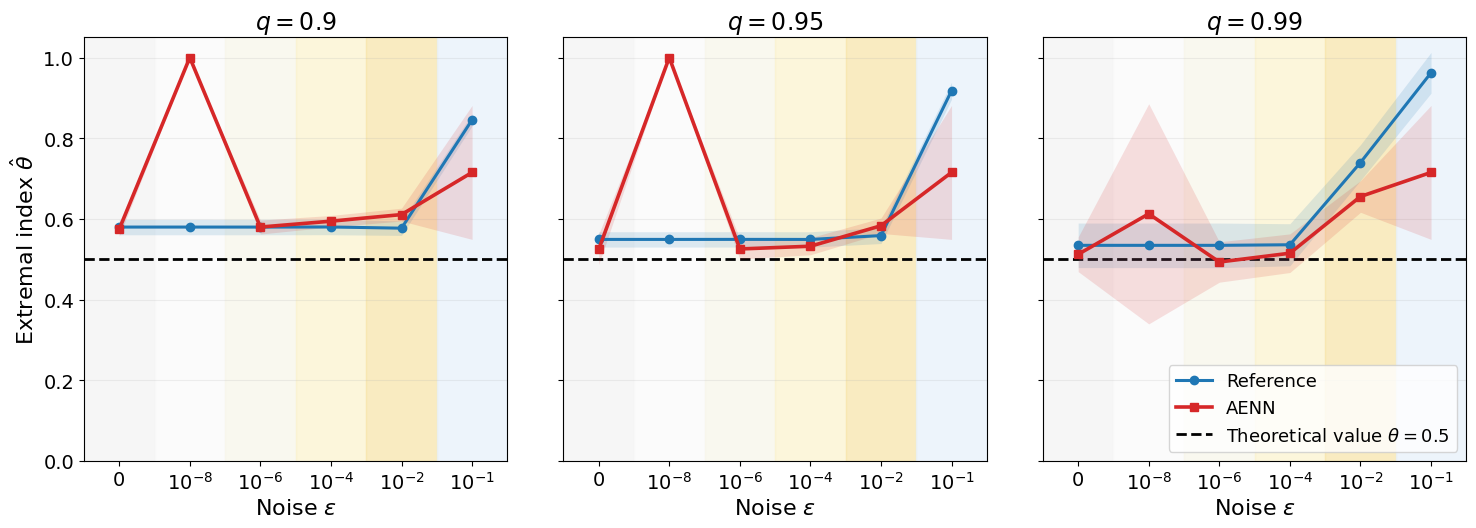

Saved: results_logistic_istar_min0.05_paired_trajectory_tanh_h128_alltrain_e1000_lr0.003/figures/logistic_shape_over_k_selected_noise.png
Saved: results_logistic_istar_min0.05_paired_trajectory_tanh_h128_alltrain_e1000_lr0.003/figures/logistic_shape_over_k_selected_noise.pdf


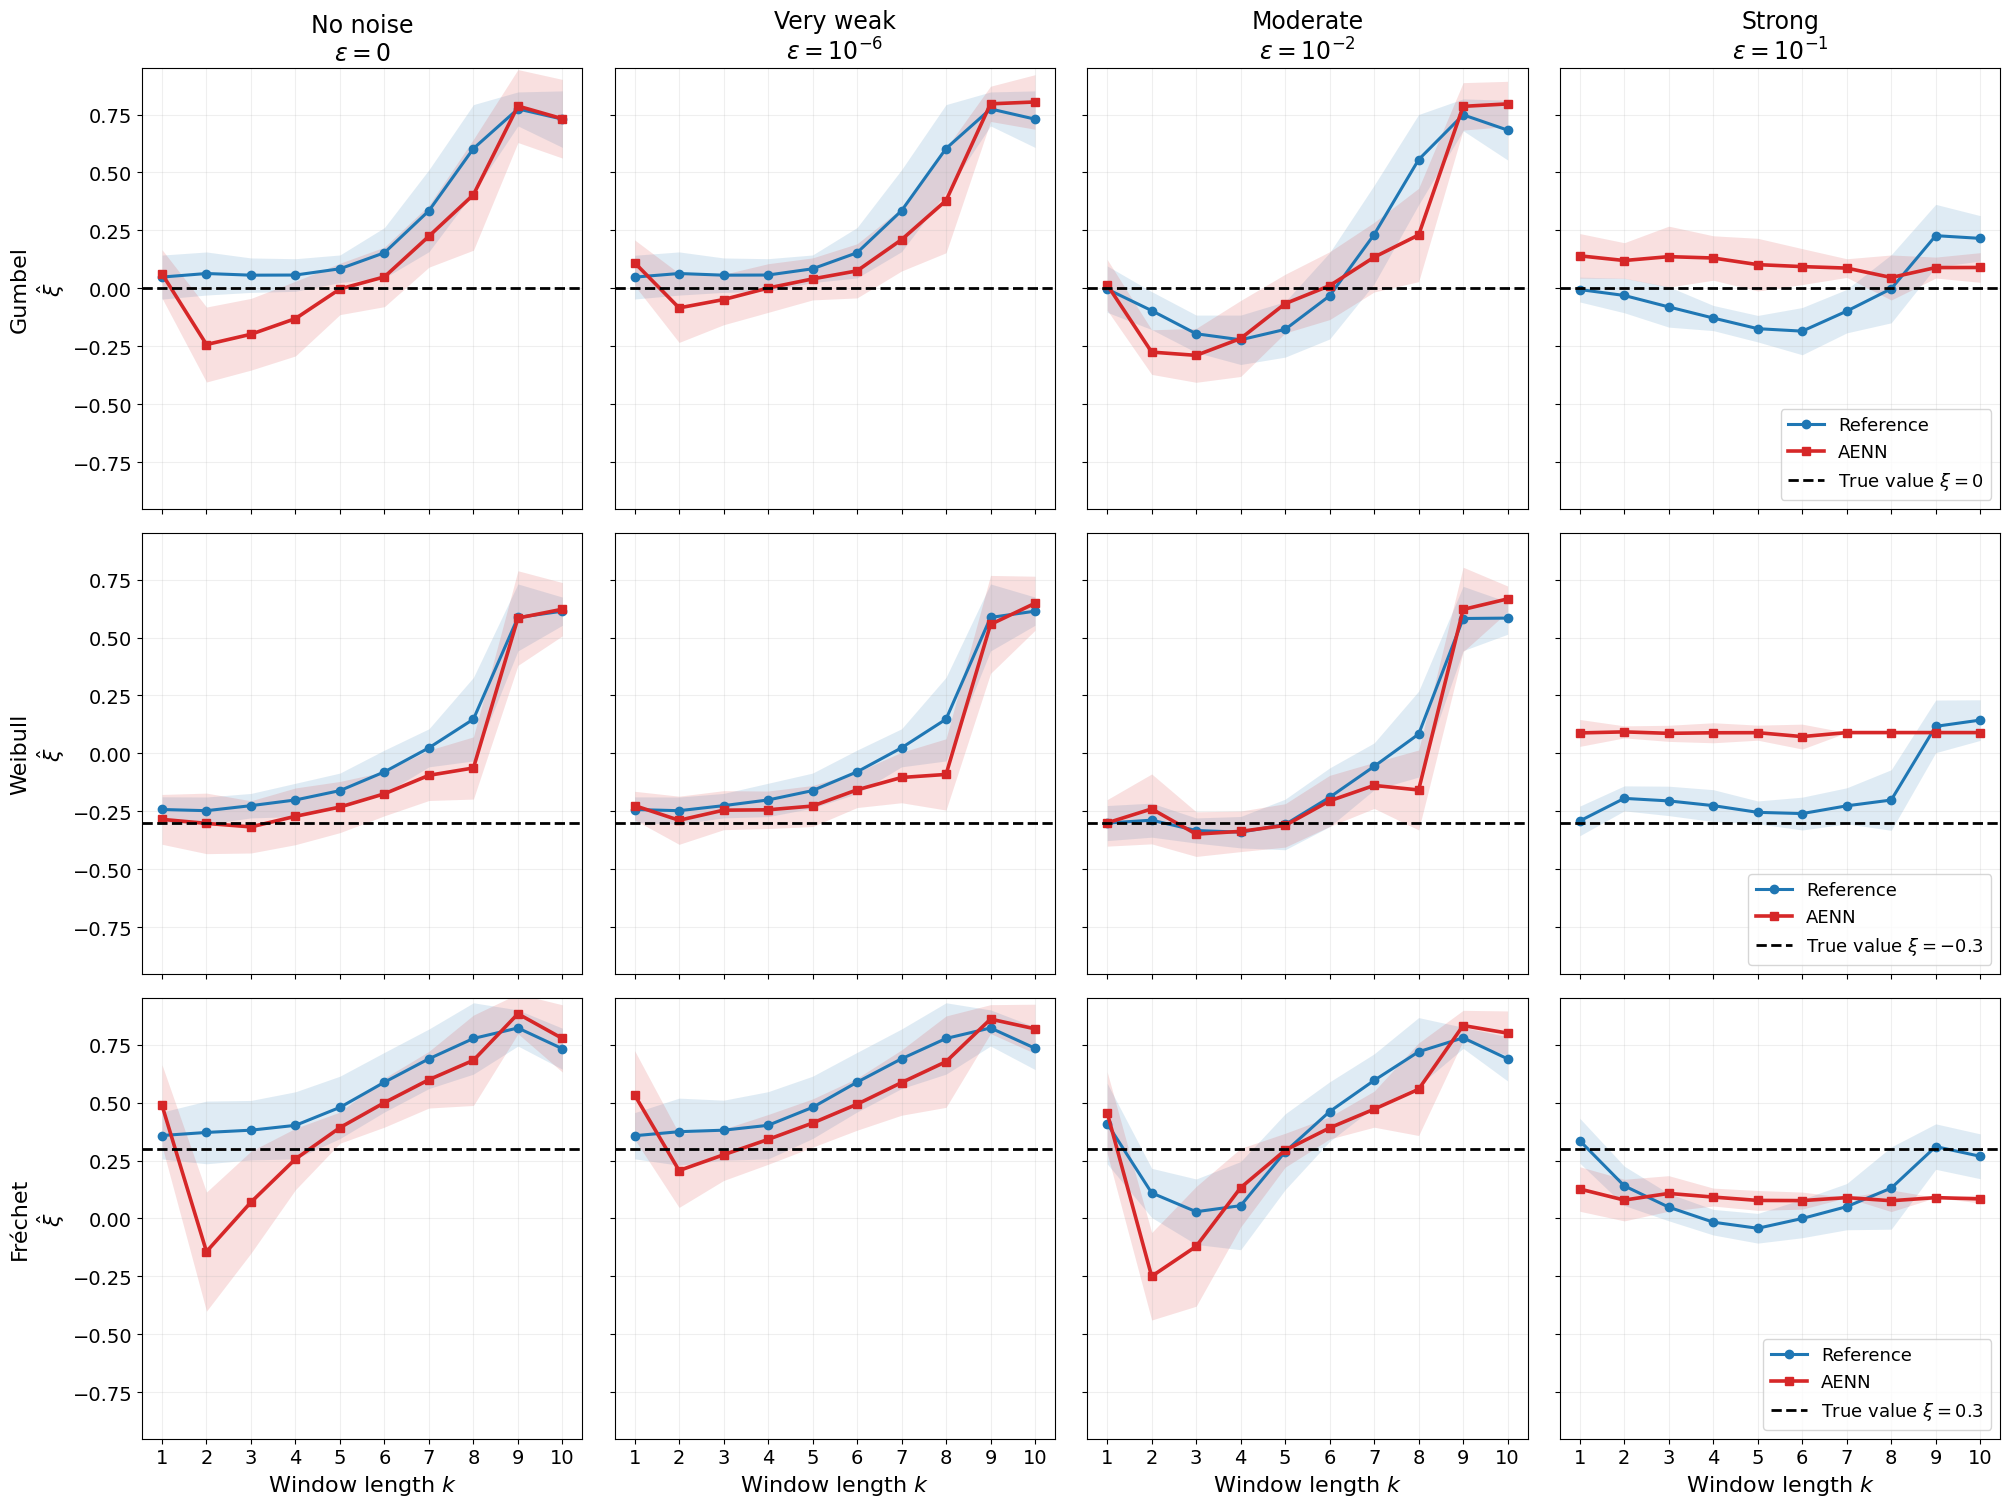

Saved: results_logistic_istar_min0.05_paired_trajectory_tanh_h128_alltrain_e1000_lr0.003/figures/logistic_return_map_density_selected_noise.png
Saved: results_logistic_istar_min0.05_paired_trajectory_tanh_h128_alltrain_e1000_lr0.003/figures/logistic_return_map_density_selected_noise.pdf


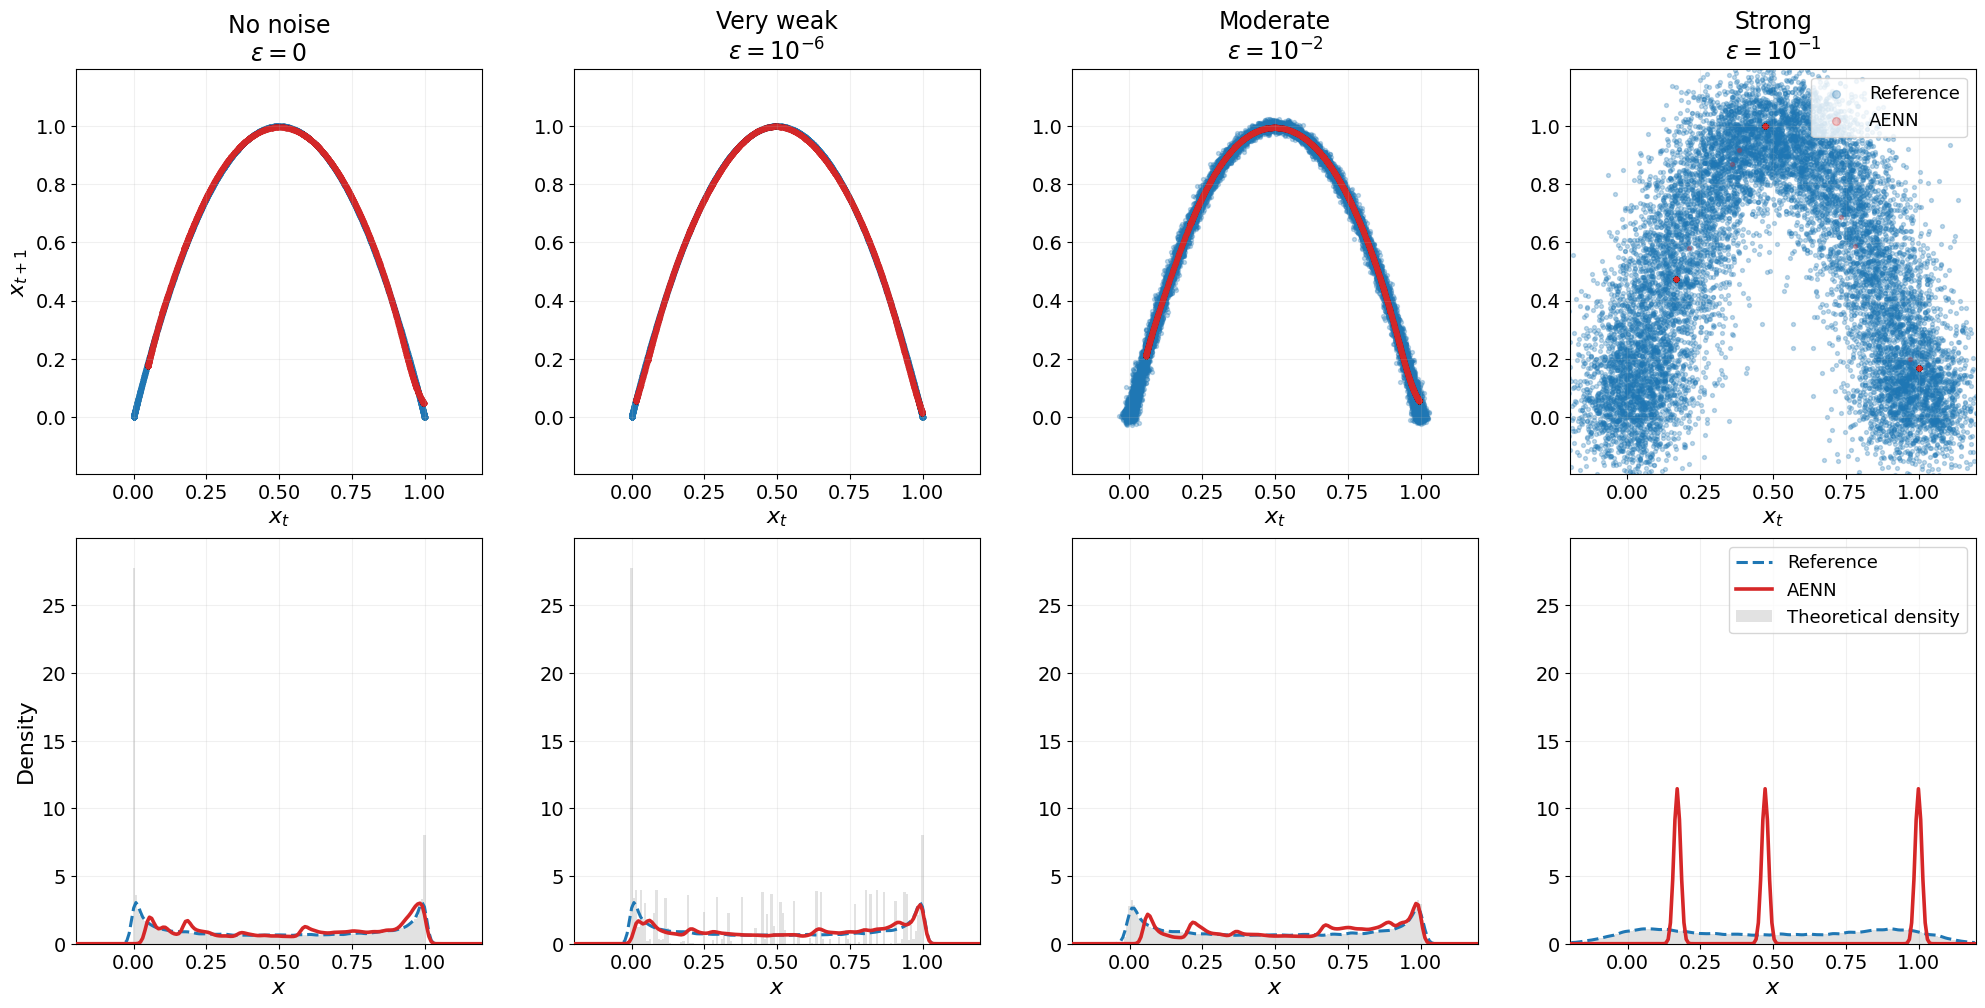

Saved: results_logistic_istar_min0.05_paired_trajectory_tanh_h128_alltrain_e1000_lr0.003/figures/logistic_istar_used_diagnostic.png
Saved: results_logistic_istar_min0.05_paired_trajectory_tanh_h128_alltrain_e1000_lr0.003/figures/logistic_istar_used_diagnostic.pdf


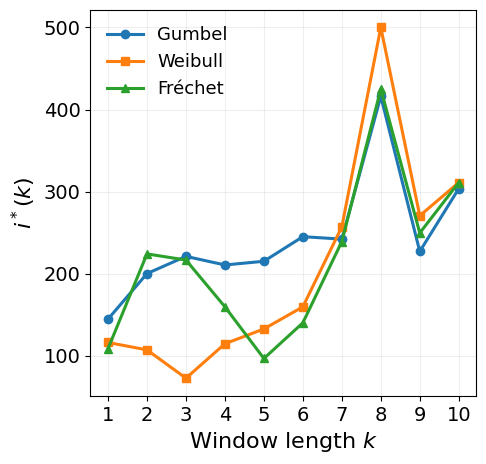


Publication outputs written to:
  Figures: results_logistic_istar_min0.05_paired_trajectory_tanh_h128_alltrain_e1000_lr0.003/figures
  Tables : results_logistic_istar_min0.05_paired_trajectory_tanh_h128_alltrain_e1000_lr0.003/tables


In [ ]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from IPython.display import display


REF_COLOR        = 'tab:blue'
AENN_COLOR       = 'tab:red'
THEORY_COLOR     = 'black'
THEORY_BAR_COLOR = 'lightgray'

THETA_TRUE = 0.5
ZETA_LOGISTIC = 0.75

XI_TRUE = {
    'Gumbel':  0.0,
    'Weibull': -0.3,
    'Frechet':  0.3,
}

OBS_ORDER   = ['Gumbel', 'Weibull', 'Frechet']
MODEL_ORDER = ['Reference', 'AENN']
MODEL_LABEL = {'Reference': 'Reference', 'AENN': 'AENN'}

# Selected plots: no noise / weak / moderate / strong
SHAPE_SELECTED_NOISES          = [0.0, 1e-6, 1e-2, 1e-1]
RETURN_DENSITY_SELECTED_NOISES = [0.0, 1e-6, 1e-2, 1e-1]
EI_TABLE_SELECTED_NOISES       = [0.0, 1e-8, 1e-6, 1e-4, 1e-2, 1e-1]

DENSITY_BINS       = 180
DENSITY_SMOOTH     = 1.5
THEORY_QUAD_POINTS = 100_000
RETURN_PLOT_MAX_POINTS = 12_000
PLOT_DPI = 220

# ------------------------------------------------------------
# Unified physical / visual scale across ALL main figures
# ------------------------------------------------------------
PANEL_SIZE  = 5.1

LINE_MAIN   = 2.6
LINE_REF    = 2.2
LINE_THEORY = 2.0

MARKER_MS   = 6.0
SCATTER_S   = 8.0

FONT_BASE   = 15
FONT_TITLE  = 17
FONT_LABEL  = 16
FONT_TICK   = 14
FONT_LEGEND = 13

plt.rcParams.update({
    'font.size': FONT_BASE,
    'axes.titlesize': FONT_TITLE,
    'axes.labelsize': FONT_LABEL,
    'xtick.labelsize': FONT_TICK,
    'ytick.labelsize': FONT_TICK,
    'legend.fontsize': FONT_LEGEND,
    'figure.titlesize': FONT_TITLE,
})

# ============================================================
# RESOLVE THE CORRECT LOGISTIC RESULT DIRECTORY
# ============================================================

EXPECTED_OUT = (
    f'results_logistic_istar_{ISTAR_RULE}{ISTAR_ALPHA:g}_'
    f'{ISTAR_MODE}_{SAMPLER}_{ACT}_h{HIDDEN_DIM}_'
    f'alltrain_e{EPOCHS}_lr{LR:g}'
)

REQUIRED_RESULT_FILES = [
    'pertrial_gev_xi.csv',
    'pertrial_ei.csv',
    'block_sizes_selected.csv',
]

def _has_complete_results(folder):
    return (
        os.path.isdir(folder)
        and all(os.path.isfile(os.path.join(folder, f))
                for f in REQUIRED_RESULT_FILES)
    )

def _candidate_logistic_result_dirs():
    """Find only Logistic result directories; never select Doubling."""
    candidates = []

    # Exact configured directory first.
    if os.path.isdir(EXPECTED_OUT):
        candidates.append(EXPECTED_OUT)

    # Then any Logistic results directory in the current working directory.
    for p in sorted(
        glob.glob('results_logistic_istar_*'),
        key=lambda x: os.path.getmtime(x) if os.path.exists(x) else 0,
        reverse=True,
    ):
        if os.path.isdir(p) and p not in candidates:
            candidates.append(p)

    return candidates

# Use the exact configured directory if it is complete.
if _has_complete_results(EXPECTED_OUT):
    OUT = EXPECTED_OUT
else:
    # If OUT was stale (for example, pointing to a Doubling directory),
    # look ONLY among Logistic result directories for a complete run.
    complete_candidates = [
        p for p in _candidate_logistic_result_dirs()
        if _has_complete_results(p)
    ]

    if complete_candidates:
        OUT = complete_candidates[0]
        print('Configured Logistic folder was incomplete; using the most recent')
        print('complete Logistic result directory instead:')
        print(' ', OUT)
    else:
        # Keep the expected path in the error so the message is actionable.
        OUT = EXPECTED_OUT
        found_dirs = _candidate_logistic_result_dirs()

        details = []
        for p in found_dirs:
            present = sorted(os.listdir(p)) if os.path.isdir(p) else []
            missing_here = [
                f for f in REQUIRED_RESULT_FILES
                if not os.path.isfile(os.path.join(p, f))
            ]
            details.append(
                f'  {p}\n'
                f'    missing: {missing_here}\n'
                f'    present: {present}'
            )

        raise FileNotFoundError(
            'Block 6 could not find a COMPLETE Logistic experiment result folder.\n\n'
            f'Expected configured directory:\n  {EXPECTED_OUT}\n\n'
            'Required files:\n  '
            + '\n  '.join(REQUIRED_RESULT_FILES)
            + '\n\n'
            + (
                'Logistic result directories found:\n'
                + '\n'.join(details)
                if details
                else
                'No results_logistic_istar_* directory was found.'
            )
            + '\n\nRun Block 5 successfully before Block 6.'
        )

FIGDIR   = os.path.join(OUT, 'figures')
TABLEDIR = os.path.join(OUT, 'tables')
os.makedirs(FIGDIR, exist_ok=True)
os.makedirs(TABLEDIR, exist_ok=True)

# ============================================================
# LOAD RESULTS
# ============================================================

GEV_PATH = os.path.join(OUT, 'pertrial_gev_xi.csv')
EI_PATH  = os.path.join(OUT, 'pertrial_ei.csv')
BLK_PATH = os.path.join(OUT, 'block_sizes_selected.csv')

print('Using Logistic results from:', OUT)
print('GEV file   :', GEV_PATH)
print('EI file    :', EI_PATH)
print('Block file :', BLK_PATH)

gev = pd.read_csv(GEV_PATH)
ei  = pd.read_csv(EI_PATH)
blk = pd.read_csv(BLK_PATH)

# Validate the actual CSV schemas written by run_experiment_istar.py.
required_gev = {'map', 'observable', 'k', 'noise', 'trial', 'model', 'xi'}
required_ei  = {'map', 'observable', 'q', 'noise', 'trial', 'model', 'ei'}
required_blk = {'map', 'observable', 'noise', 'trial', 'model', 'k', 'i_star'}

for name, df, req in [
    ('pertrial_gev_xi.csv', gev, required_gev),
    ('pertrial_ei.csv', ei, required_ei),
    ('block_sizes_selected.csv', blk, required_blk),
]:
    miss = req.difference(df.columns)
    if miss:
        raise ValueError(
            f'{name} has an unexpected schema. Missing columns: {sorted(miss)}\n'
            f'Available columns: {list(df.columns)}'
        )

for df in (gev, ei, blk):
    df['noise'] = pd.to_numeric(df['noise'], errors='coerce')

# Logistic only.  If a wrong folder somehow slipped through, fail loudly.
for name, df in [('GEV', gev), ('EI', ei), ('block-size', blk)]:
    maps_here = set(df['map'].astype(str).str.lower().dropna().unique())
    if 'logistic' not in maps_here:
        raise ValueError(
            f'{name} results do not contain Logistic data. '
            f'Found map values: {sorted(maps_here)}'
        )

gev = gev[gev['map'].astype(str).str.lower().eq('logistic')].copy()
ei  = ei[ei['map'].astype(str).str.lower().eq('logistic')].copy()
blk = blk[blk['map'].astype(str).str.lower().eq('logistic')].copy()

gev['xi_true'] = gev['observable'].map(XI_TRUE)

ALL_NOISES = sorted(float(x) for x in gev['noise'].dropna().unique())
print('Available Logistic noise levels:', ALL_NOISES)
print('Target zeta =', ZETA_LOGISTIC, '| theoretical theta =', THETA_TRUE)

# ============================================================
# HELPERS
# ============================================================

def _noise_mask(series, target):
    """Strict noise matching; 1e-8 is never confused with zero."""
    arr = pd.to_numeric(series, errors='coerce').to_numpy(dtype=float)
    target = float(target)
    if target == 0.0:
        return arr == 0.0
    return np.isclose(arr, target, rtol=1e-10, atol=0.0)


def _available_noise(target, available=None):
    """Return the exact requested level if available; otherwise None."""
    if available is None:
        available = ALL_NOISES
    a = np.asarray(available, dtype=float)
    target = float(target)

    if target == 0.0:
        hit = a[a == 0.0]
        return float(hit[0]) if len(hit) else None

    hit = a[np.isclose(a, target, rtol=1e-10, atol=0.0)]
    return float(hit[0]) if len(hit) else None


def _eps_tex(eps):
    """TeX body for epsilon value, WITHOUT surrounding $...$."""
    eps = float(eps)
    if eps == 0.0:
        return '0'
    exponent = int(np.round(np.log10(abs(eps))))
    if np.isclose(abs(eps), 10.0**exponent, rtol=1e-10, atol=0.0):
        return rf'10^{{{exponent}}}'
    return f'{eps:g}'


def _eps_label(eps, math=True):
    """Standalone epsilon tick/table label."""
    eps = float(eps)
    if eps == 0.0:
        return '0'
    exponent = int(np.round(np.log10(abs(eps))))
    if np.isclose(abs(eps), 10.0**exponent, rtol=1e-10, atol=0.0):
        return rf'$10^{{{exponent}}}$' if math else f'1e{exponent:+03d}'
    return f'{eps:g}'


def _noise_regime(eps):
    eps = float(eps)
    if eps == 0.0:
        return 'No noise'
    if eps <= 1e-8:
        return 'Negligible'
    if eps <= 1e-6:
        return 'Very weak'
    if eps <= 1e-4:
        return 'Weak'
    if eps <= 1e-2:
        return 'Moderate'
    return 'Strong'


def _fmt_mean_sd(values, digits=3):
    x = pd.to_numeric(pd.Series(values), errors='coerce').dropna().to_numpy(float)
    if x.size == 0:
        return '—', 0
    mean = float(np.mean(x))
    sd = float(np.std(x, ddof=1)) if x.size > 1 else 0.0
    return f'{mean:.{digits}f} ({sd:.{digits}f})', int(x.size)


def _save_figure(fig, stem):
    png = os.path.join(FIGDIR, stem + '.png')
    pdf = os.path.join(FIGDIR, stem + '.pdf')
    fig.savefig(png, dpi=PLOT_DPI, bbox_inches='tight')
    fig.savefig(pdf, bbox_inches='tight')
    print('Saved:', png)
    print('Saved:', pdf)


def _make_axes_square(axarr):
    """Force every subplot box to be square."""
    for ax in np.asarray(axarr, dtype=object).ravel():
        try:
            ax.set_box_aspect(1)
        except Exception:
            pass
        ax.tick_params(axis='both', which='major', labelsize=FONT_TICK)


def _mean_sd_by_k(h, model, ks):
    means, sds = [], []
    for k in ks:
        x = pd.to_numeric(
            h[(h['model'] == model) & (h['k'] == k)]['xi'],
            errors='coerce'
        ).dropna().to_numpy(float)
        means.append(np.mean(x) if len(x) else np.nan)
        sds.append(
            np.std(x, ddof=1) if len(x) > 1
            else (0.0 if len(x) == 1 else np.nan)
        )
    return np.asarray(means, float), np.asarray(sds, float)


def _finite_1d(x):
    x = np.asarray(x, dtype=float).reshape(-1)
    return x[np.isfinite(x)]


def _density_curve(x, edges):
    x = _finite_1d(x)
    centres = 0.5 * (edges[:-1] + edges[1:])

    if x.size == 0:
        return centres, np.full_like(centres, np.nan, dtype=float)

    h, e = np.histogram(x, bins=edges, density=True)

    if DENSITY_SMOOTH > 0:
        h = gaussian_filter1d(h.astype(float), sigma=DENSITY_SMOOTH)
        dx = e[1] - e[0]
        area = np.sum(h) * dx
        if np.isfinite(area) and area > 0:
            h = h / area

    return 0.5 * (e[:-1] + e[1:]), h


def _logistic_clean_density(x):
    """
    Invariant density of L(x)=4x(1-x):
        rho(x) = 1 / [pi sqrt{x(1-x)}],  0<x<1.
    """
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x, dtype=float)
    inside = (x > 0.0) & (x < 1.0)
    out[inside] = 1.0 / (
        np.pi * np.sqrt(x[inside] * (1.0 - x[inside]))
    )
    return out


_THEORY_X_SAMPLES = None

def _theoretical_logistic_density(x, eps):
    """
    Theoretical observed-state density.

    Clean case:
        X ~ Logistic invariant measure,
        rho(x)=1/[pi sqrt{x(1-x)}].

    Observational-noise case:
        Y = X + eps Z,  Z~N(0,1),
    so rho_eps is the Gaussian convolution of the Logistic invariant density.

    We compute the convolution deterministically using midpoint quadrature
    under the exact inverse-CDF representation
        X = sin^2(pi U / 2),  U~Uniform(0,1).
    """
    x = np.asarray(x, dtype=float)
    eps = float(eps)

    if eps == 0.0:
        return _logistic_clean_density(x)


    global _THEORY_X_SAMPLES

    if _THEORY_X_SAMPLES is None or len(_THEORY_X_SAMPLES) != THEORY_QUAD_POINTS:
        u = (np.arange(THEORY_QUAD_POINTS, dtype=float) + 0.5) / THEORY_QUAD_POINTS
        _THEORY_X_SAMPLES = np.sin(0.5 * np.pi * u) ** 2

    xs = _THEORY_X_SAMPLES
    out = np.zeros_like(x, dtype=float)
    norm = eps * np.sqrt(2.0 * np.pi)

    # Chunk over invariant-measure quadrature points to keep memory modest.
    chunk = 10_000
    for s in range(0, xs.size, chunk):
        xx = xs[s:s + chunk]
        z = (x[:, None] - xx[None, :]) / eps
        out += np.exp(-0.5 * z * z).sum(axis=1)

    out /= (xs.size * norm)
    return out


def _return_pairs(x, max_points=RETURN_PLOT_MAX_POINTS):
    a = _finite_1d(x)
    if a.size < 2:
        return np.empty(0), np.empty(0)

    x0, x1 = a[:-1], a[1:]
    ok = np.isfinite(x0) & np.isfinite(x1)
    x0, x1 = x0[ok], x1[ok]

    if max_points and x0.size > max_points:
        idx = np.linspace(0, x0.size - 1, int(max_points), dtype=int)
        x0, x1 = x0[idx], x1[idx]

    return x0, x1


# ============================================================
# A. NUMERICAL SUMMARY FILES
# ============================================================

xi_numeric = (
    gev.groupby(['map', 'observable', 'k', 'noise', 'model'])['xi']
       .agg(n='count', mean='mean', sd='std')
       .reset_index()
)
xi_numeric['xi_true'] = xi_numeric['observable'].map(XI_TRUE)
xi_numeric['bias'] = xi_numeric['mean'] - xi_numeric['xi_true']
xi_numeric.to_csv(
    os.path.join(OUT, 'summary_xi_istar.csv'),
    index=False
)

istar_used = (
    blk.groupby(['map', 'observable', 'k'])['i_star']
       .agg(['median', 'min', 'max'])
       .reset_index()
)
istar_used.to_csv(
    os.path.join(OUT, 'summary_istar_used.csv'),
    index=False
)


# ============================================================
# B. TABLE: GEV SHAPE AT k=1 ACROSS ALL NOISE LEVELS
# ============================================================

shape_rows = []
shape_n_rows = []

for eps in ALL_NOISES:
    row = {
        'Noise epsilon': _eps_label(eps, math=False),
        'Regime': _noise_regime(eps),
    }
    nrow = {'Noise epsilon': _eps_label(eps, math=False)}

    for ob in OBS_ORDER:
        for mdl in MODEL_ORDER:
            vals = gev[
                (gev['k'] == 1)
                & (gev['observable'] == ob)
                & (gev['model'] == mdl)
                & _noise_mask(gev['noise'], eps)
            ]['xi']

            txt, n = _fmt_mean_sd(vals)
            col = f'{ob} | {MODEL_LABEL[mdl]}'
            row[col] = txt
            nrow[col] = n

    shape_rows.append(row)
    shape_n_rows.append(nrow)

shape_k1_table = pd.DataFrame(shape_rows)
shape_k1_n = pd.DataFrame(shape_n_rows)

shape_k1_table.to_csv(
    os.path.join(TABLEDIR, 'table_shape_k1_all_noise_mean_sd.csv'),
    index=False
)
shape_k1_n.to_csv(
    os.path.join(TABLEDIR, 'table_shape_k1_all_noise_valid_n.csv'),
    index=False
)

with open(
    os.path.join(TABLEDIR, 'table_shape_k1_all_noise_mean_sd.tex'),
    'w'
) as f:
    f.write(shape_k1_table.to_latex(index=False, escape=False))

print('\nLogistic GEV shape at k=1 across all noise levels: mean (SD)')
display(shape_k1_table)


# ============================================================
# C. TABLES: EXTREMAL INDEX
# ============================================================

Q_ORDER = [
    q for q in [0.90, 0.95, 0.99]
    if np.any(np.isclose(ei['q'], q, rtol=0, atol=1e-12))
]
if not Q_ORDER:
    Q_ORDER = sorted(ei['q'].dropna().unique())


def _build_ei_table(noises):
    rows, nrows = [], []

    available_ei_noises = sorted(float(x) for x in ei['noise'].dropna().unique())

    for eps0 in noises:
        eps = _available_noise(eps0, available_ei_noises)
        if eps is None:
            continue

        row = {
            'Noise epsilon': _eps_label(eps, math=False),
            'Regime': _noise_regime(eps),
        }
        nrow = {'Noise epsilon': _eps_label(eps, math=False)}

        for q in Q_ORDER:
            for mdl in MODEL_ORDER:
                vals = ei[
                    np.isclose(
                        ei['q'].to_numpy(float),
                        float(q),
                        rtol=0,
                        atol=1e-12
                    )
                    & (ei['model'] == mdl).to_numpy()
                    & _noise_mask(ei['noise'], eps)
                ]['ei']

                txt, n = _fmt_mean_sd(vals)
                col = f'q={q:g} | {MODEL_LABEL[mdl]}'
                row[col] = txt
                nrow[col] = n

        rows.append(row)
        nrows.append(nrow)

    return pd.DataFrame(rows), pd.DataFrame(nrows)


ei_table_all, ei_n_all = _build_ei_table(
    sorted(float(x) for x in ei['noise'].dropna().unique())
)
ei_table_main, ei_n_main = _build_ei_table(EI_TABLE_SELECTED_NOISES)

ei_table_all.to_csv(
    os.path.join(TABLEDIR, 'table_ei_all_noise_mean_sd.csv'),
    index=False
)
ei_n_all.to_csv(
    os.path.join(TABLEDIR, 'table_ei_all_noise_valid_n.csv'),
    index=False
)
ei_table_main.to_csv(
    os.path.join(TABLEDIR, 'table_ei_selected_noise_mean_sd.csv'),
    index=False
)
ei_n_main.to_csv(
    os.path.join(TABLEDIR, 'table_ei_selected_noise_valid_n.csv'),
    index=False
)

with open(
    os.path.join(TABLEDIR, 'table_ei_selected_noise_mean_sd.tex'),
    'w'
) as f:
    f.write(ei_table_main.to_latex(index=False, escape=False))

print('\nLogistic extremal-index selected-noise table: mean (SD)')
display(ei_table_main)


# Warn if finite-only summaries have fewer than requested trials.
for name, nt in [
    ('shape k=1', shape_k1_n),
    ('EI selected', ei_n_main),
]:
    numeric = (
        nt.drop(columns=['Noise epsilon'], errors='ignore')
          .apply(pd.to_numeric, errors='coerce')
    )
    if numeric.size and np.nanmin(numeric.to_numpy(float)) < TRIALS:
        print(
            f'NOTE: {name} contains cells with fewer than {TRIALS} finite estimates. '
            'See the corresponding *_valid_n.csv file.'
        )


# ============================================================
# D. FIGURE 1: EXTREMAL INDEX ACROSS ALL NOISE LEVELS
# ============================================================

EI_NOISES = sorted(float(x) for x in ei['noise'].dropna().unique())
xpos = np.arange(len(EI_NOISES), dtype=float)

fig, axes = plt.subplots(
    1, len(Q_ORDER),
    figsize=(PANEL_SIZE * len(Q_ORDER), PANEL_SIZE),
    sharex=True,
    sharey=True,
    squeeze=False
)
axes = axes[0]
_make_axes_square(axes)

# Background bands by noise regime.
regime_spans = []
for reg in [
    'No noise', 'Negligible', 'Very weak',
    'Weak', 'Moderate', 'Strong'
]:
    ids = [
        i for i, eps in enumerate(EI_NOISES)
        if _noise_regime(eps) == reg
    ]
    if ids:
        regime_spans.append(
            (reg, min(ids) - 0.5, max(ids) + 0.5)
        )

regime_face = {
    'No noise':   '#f4f4f4',
    'Negligible': '#fafafa',
    'Very weak':  '#f8f6ea',
    'Weak':       '#fbf3cf',
    'Moderate':   '#f8e5ac',
    'Strong':     '#e8f1fa',
}

for j, q in enumerate(Q_ORDER):
    ax = axes[j]

    for reg, left, right in regime_spans:
        ax.axvspan(
            left, right,
            color=regime_face[reg],
            alpha=0.75,
            zorder=0
        )

    for mdl, col, marker in [
        ('Reference', REF_COLOR, 'o'),
        ('AENN', AENN_COLOR, 's'),
    ]:
        means, sds = [], []

        for eps in EI_NOISES:
            v = pd.to_numeric(
                ei[
                    np.isclose(
                        ei['q'].to_numpy(float),
                        float(q),
                        rtol=0,
                        atol=1e-12
                    )
                    & (ei['model'] == mdl).to_numpy()
                    & _noise_mask(ei['noise'], eps)
                ]['ei'],
                errors='coerce'
            ).dropna().to_numpy(float)

            means.append(np.mean(v) if len(v) else np.nan)
            sds.append(
                np.std(v, ddof=1) if len(v) > 1
                else (0.0 if len(v) == 1 else np.nan)
            )

        means = np.asarray(means, float)
        sds = np.asarray(sds, float)

        ax.plot(
            xpos, means,
            marker=marker,
            ms=MARKER_MS,
            lw=(LINE_REF if mdl == 'Reference' else LINE_MAIN),
            color=col,
            label=MODEL_LABEL[mdl],
            zorder=3
        )
        ax.fill_between(
            xpos,
            means - sds,
            means + sds,
            color=col,
            alpha=0.14,
            linewidth=0,
            zorder=2
        )

    ax.axhline(
        THETA_TRUE,
        color=THEORY_COLOR,
        ls='--',
        lw=LINE_THEORY,
        label=rf'Theoretical value $\theta={THETA_TRUE:g}$',
        zorder=1
    )

    ax.set_title(rf'$q={q:g}$', fontsize=FONT_TITLE)
    ax.set_ylim(0.0, 1.05)
    ax.set_xlim(-0.5, len(EI_NOISES) - 0.5)
    ax.set_xticks(xpos)
    ax.set_xticklabels(
        [_eps_label(eps) for eps in EI_NOISES],
        rotation=0
    )
    ax.set_xlabel(r'Noise $\epsilon$')
    ax.grid(alpha=0.20, axis='y')

    if j == 0:
        ax.set_ylabel(r'Extremal index $\hat\theta$')

# One legend, bottom-right of the rightmost panel.
handles, labels = axes[-1].get_legend_handles_labels()
uniq = dict(zip(labels, handles))
axes[-1].legend(
    uniq.values(),
    uniq.keys(),
    loc='lower right',
    fontsize=FONT_LEGEND,
    frameon=True
)

fig.tight_layout()
_save_figure(fig, 'logistic_ei_all_noise_all_thresholds')
plt.show()


# ============================================================
# E. FIGURE 2: GEV SHAPE OVER k
#    Rows    : Gumbel / Weibull / Frechet
# ============================================================

shape_noises = []
for eps0 in SHAPE_SELECTED_NOISES:
    eps = _available_noise(eps0, ALL_NOISES)
    if eps is not None and eps not in shape_noises:
        shape_noises.append(eps)

fig, axes = plt.subplots(
    len(OBS_ORDER),
    len(shape_noises),
    figsize=(PANEL_SIZE * len(shape_noises), PANEL_SIZE * len(OBS_ORDER)),
    sharex=True,
    sharey=True,
    squeeze=False
)
_make_axes_square(axes)

for i, ob in enumerate(OBS_ORDER):
    for j, eps in enumerate(shape_noises):
        ax = axes[i, j]

        h = gev[
            (gev['observable'] == ob)
            & _noise_mask(gev['noise'], eps)
        ]
        ks = sorted(int(k) for k in h['k'].dropna().unique())

        for mdl, col, marker in [
            ('Reference', REF_COLOR, 'o'),
            ('AENN', AENN_COLOR, 's'),
        ]:
            m, sd = _mean_sd_by_k(h, mdl, ks)
            kk = np.asarray(ks, float)

            ax.plot(
                kk, m,
                marker=marker,
                ms=MARKER_MS,
                lw=(LINE_REF if mdl == 'Reference' else LINE_MAIN),
                color=col,
                label=MODEL_LABEL[mdl]
            )
            ax.fill_between(
                kk,
                m - sd,
                m + sd,
                color=col,
                alpha=0.14,
                linewidth=0
            )

        ax.axhline(
            XI_TRUE[ob],
            color=THEORY_COLOR,
            ls='--',
            lw=LINE_THEORY,
            label=rf'True value $\xi={XI_TRUE[ob]:g}$'
        )

        ax.set_ylim(-0.95, 0.95)
        ax.set_xticks(ks)
        ax.grid(alpha=0.20)

        if i == 0:
            ax.set_title(
                _noise_regime(eps)
                + '\n'
                + rf'$\epsilon={_eps_tex(eps)}$',
                fontsize=FONT_TITLE
            )

        if j == 0:
            pretty = 'Fréchet' if ob == 'Frechet' else ob
            ax.set_ylabel(
                pretty + '\n' + r'$\hat\xi$',
                fontsize=FONT_LABEL
            )

        if i == len(OBS_ORDER) - 1:
            ax.set_xlabel(r'Window length $k$')

    # Same legend position as the EI figure: lower right.
    handles, labels = axes[i, -1].get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    axes[i, -1].legend(
        uniq.values(),
        uniq.keys(),
        loc='lower right',
        fontsize=FONT_LEGEND,
        frameon=True
    )

fig.tight_layout()
_save_figure(fig, 'logistic_shape_over_k_selected_noise')
plt.show()


# ============================================================
# F. FIGURE 3: RETURN MAP + DENSITY
#    Selected levels: no noise / weak / moderate / strong
# ============================================================

RETURN_DIR = os.path.join(OUT, 'return_maps')
return_files = sorted(
    glob.glob(
        os.path.join(
            RETURN_DIR,
            'return_map_data_*.npz'
        )
    )
)

return_cases = []

for fn in return_files:
    try:
        z = np.load(fn, allow_pickle=False)

        eps = (
            float(np.asarray(z['noise']).reshape(-1)[0])
            if 'noise' in z.files else np.nan
        )
        trial = (
            int(np.asarray(z['trial']).reshape(-1)[0])
            if 'trial' in z.files else RETURN_MAP_TRIAL
        )
        mp = (
            str(np.asarray(z['map']).reshape(-1)[0])
            if 'map' in z.files else 'Logistic'
        )

        # Logistic only
        if str(mp).lower() != 'logistic':
            continue

        return_cases.append({
            'file': fn,
            'eps': eps,
            'trial': trial,
            'map': mp,
            'reference': _finite_1d(z['reference']),
            'aenn': _finite_1d(z['aenn']),
        })

    except Exception as exc:
        print('Skipping unreadable return-map file:', fn, exc)


selected_cases = []
available_return_noises = sorted({
    float(c['eps'])
    for c in return_cases
    if np.isfinite(c['eps'])
})

for eps0 in RETURN_DENSITY_SELECTED_NOISES:
    eps = _available_noise(
        eps0,
        available_return_noises
    )

    if eps is None:
        continue

    matches = [
        c for c in return_cases
        if _noise_mask(
            pd.Series([c['eps']]),
            eps
        )[0]
    ]

    # Prefer the configured representative paired orbit.
    trial_matches = [
        c for c in matches
        if c['trial'] == RETURN_MAP_TRIAL
    ]

    c = (
        trial_matches[0]
        if trial_matches
        else (matches[0] if matches else None)
    )

    if c is not None:
        selected_cases.append(c)


if selected_cases:

    # --------------------------------------------------------
    # Common return-map axis range
    # --------------------------------------------------------
    rv = []

    for c in selected_cases:
        r0, r1 = _return_pairs(c['reference'])
        a0, a1 = _return_pairs(c['aenn'])

        if len(r0):
            rv.extend([r0, r1])
        if len(a0):
            rv.extend([a0, a1])

    rv = (
        np.concatenate(rv)
        if rv
        else np.array([0.0, 1.0])
    )

    qlo, qhi = np.nanquantile(
        rv,
        [0.001, 0.999]
    )

    rlo = min(float(qlo), 0.0)
    rhi = max(float(qhi), 1.0)

    rpad = 0.035 * max(
        rhi - rlo,
        1e-8
    )

    rlo, rhi = (
        rlo - rpad,
        rhi + rpad
    )

    # --------------------------------------------------------
    # Common density x-range
    # --------------------------------------------------------
    dv = []

    for c in selected_cases:
        if c['reference'].size:
            dv.append(c['reference'])
        if c['aenn'].size:
            dv.append(c['aenn'])

    dv = (
        np.concatenate(dv)
        if dv
        else np.array([0.0, 1.0])
    )

    qlo, qhi = np.nanquantile(
        dv,
        [0.001, 0.999]
    )

    dlo = min(float(qlo), 0.0)
    dhi = max(float(qhi), 1.0)

    dpad = 0.035 * max(
        dhi - dlo,
        1e-8
    )

    dlo, dhi = (
        dlo - dpad,
        dhi + dpad
    )

    density_edges = np.linspace(
        dlo,
        dhi,
        DENSITY_BINS + 1
    )

    # --------------------------------------------------------
    # Prepare density curves and common y-range
    # --------------------------------------------------------
    prepared_density = []
    density_ymax = 0.0

    for c in selected_cases:

        xr, dr = _density_curve(
            c['reference'],
            density_edges
        )

        xa, da = _density_curve(
            c['aenn'],
            density_edges
        )

        dt = _theoretical_logistic_density(
            xr,
            c['eps']
        )

        prepared_density.append(
            (xr, dr, xa, da, dt)
        )

        finite_y = np.concatenate([
            dr[np.isfinite(dr)],
            da[np.isfinite(da)],
            dt[np.isfinite(dt)]
        ])

        if finite_y.size:
            density_ymax = max(
                density_ymax,
                float(np.max(finite_y))
            )

    density_ymax = (
        1.08 * density_ymax
        if density_ymax > 0
        else 1.0
    )

    # --------------------------------------------------------
    # 2 x 4 square-panel layout
    # --------------------------------------------------------
    fig, axes = plt.subplots(
        2,
        len(selected_cases),
        figsize=(PANEL_SIZE * len(selected_cases), PANEL_SIZE * 2),
        squeeze=False
    )

    _make_axes_square(axes)

    for j, (c, dens) in enumerate(
        zip(
            selected_cases,
            prepared_density
        )
    ):
        eps = c['eps']
        ref = c['reference']
        aen = c['aenn']

        xr, dr, xa, da, dt = dens

        # ----------------------------------------------------
        # Top row: return map
        # ----------------------------------------------------
        ax = axes[0, j]

        r0, r1 = _return_pairs(ref)
        a0, a1 = _return_pairs(aen)

        ax.scatter(
            r0, r1,
            s=SCATTER_S,
            alpha=0.28,
            color=REF_COLOR,
            label='Reference',
            rasterized=True
        )

        ax.scatter(
            a0, a1,
            s=SCATTER_S,
            alpha=0.28,
            color=AENN_COLOR,
            label='AENN',
            rasterized=True
        )

        ax.set_xlim(rlo, rhi)
        ax.set_ylim(rlo, rhi)
        ax.set_aspect(
            'equal',
            adjustable='box'
        )

        ax.set_title(
            _noise_regime(eps)
            + '\n'
            + rf'$\epsilon={_eps_tex(eps)}$',
            fontsize=FONT_TITLE
        )

        ax.set_xlabel(r'$x_t$')

        if j == 0:
            ax.set_ylabel(r'$x_{t+1}$')

        ax.grid(alpha=0.18)
        ax.tick_params(axis='both', labelsize=FONT_TICK)

        # ----------------------------------------------------
        # Bottom row: theory bars + Reference + AENN
        # ----------------------------------------------------
        ax = axes[1, j]

        width = (
            xr[1] - xr[0]
            if len(xr) > 1
            else 0.01
        )

        if np.any(np.isfinite(dt)):
            ax.bar(
                xr,
                dt,
                width=width,
                color=THEORY_BAR_COLOR,
                alpha=0.65,
                edgecolor='none',
                align='center',
                label='Theoretical density',
                zorder=1
            )

        ax.plot(
            xr,
            dr,
            color=REF_COLOR,
            lw=LINE_REF,
            ls='--',
            label='Reference',
            zorder=3
        )

        ax.plot(
            xa,
            da,
            color=AENN_COLOR,
            lw=LINE_MAIN,
            ls='-',
            label='AENN',
            zorder=4
        )

        ax.set_xlim(dlo, dhi)
        ax.set_ylim(0, density_ymax)
        ax.set_xlabel(r'$x$')

        if j == 0:
            ax.set_ylabel('Density')

        ax.grid(alpha=0.18)
        ax.tick_params(axis='both', labelsize=FONT_TICK)

    # Return-map and density legends in the rightmost panels.
    axes[0, -1].legend(
        loc='upper right',
        fontsize=FONT_LEGEND,
        frameon=True,
        markerscale=2.0
    )

    axes[1, -1].legend(
        loc='upper right',
        fontsize=FONT_LEGEND,
        frameon=True
    )

    fig.tight_layout()
    _save_figure(
        fig,
        'logistic_return_map_density_selected_noise'
    )
    plt.show()

else:
    print(
        'No Logistic return_map_data_*.npz files were found in:\n  '
        + RETURN_DIR
        + '\nThe EI and shape figures are still valid. '
          'The return-map/density figure requires Block 5 to be run '
          'with RETURN_MAPS=True.'
    )


# ============================================================
# G. OPTIONAL DIAGNOSTIC: BLOCK LENGTHS ACTUALLY USED
# ============================================================

fig, ax = plt.subplots(
    figsize=(PANEL_SIZE, PANEL_SIZE)
)

_make_axes_square([ax])

for ob, col, marker in [
    ('Gumbel', REF_COLOR, 'o'),
    ('Weibull', 'tab:orange', 's'),
    ('Frechet', 'tab:green', '^'),
]:
    h = blk[
        blk['observable'] == ob
    ]

    if len(h):
        m = h.groupby('k')['i_star'].median()

        ax.plot(
            m.index,
            m.values,
            marker=marker,
            lw=LINE_REF,
            ms=MARKER_MS,
            color=col,
            label=(
                'Fréchet'
                if ob == 'Frechet'
                else ob
            )
        )

ax.set_xlabel(r'Window length $k$')
ax.set_ylabel(r'$i^*(k)$')
ax.set_xticks(
    sorted(
        int(k)
        for k in blk['k'].dropna().unique()
    )
)
ax.grid(alpha=0.20)
ax.legend(
    frameon=False,
    fontsize=FONT_LEGEND
)

fig.tight_layout()
_save_figure(
    fig,
    'logistic_istar_used_diagnostic'
)
plt.show()


print('\nPublication outputs written to:')
print('  Figures:', FIGDIR)
print('  Tables :', TABLEDIR)